<a href="https://www.kaggle.com/code/lalit7881/marvel-cinematic-universe-boxoffice-92-31?scriptVersionId=351252053" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib
matplotlib.use('Agg')  # Ensuring we use a non-interactive backend
import matplotlib.pyplot as plt
%matplotlib inline

from pathlib import Path

# Helper function to resolve data file paths dynamically
DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
    Path('.')  # also check current directory
]

def resolve_data_file(file_name=None, suffixes=None):
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

sns.set(style='whitegrid')  # Setting a nice theme for seaborn plots
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/parthfr/marvel-cinematic-universe-boxoffice-csv/mcu.csv


In [2]:
import warnings
warnings.filterwarnings('ignore')

## Loading dataset

In [3]:
df = pd.read_csv("/kaggle/input/datasets/parthfr/marvel-cinematic-universe-boxoffice-csv/mcu.csv")

In [4]:
df.head()

,movie_title,mcu_phase,release_date,tomato_meter,audience_score,movie_duration,production_budget,opening_weekend,domestic_box_office,worldwide_box_office
0,Iron Man,Phase 1,2008-05-02,94,91,126.0,140000000.0,102118668.0,319034126.0,585796247.0
1,The Incredible Hulk,Phase 1,2008-06-13,67,70,112.0,137500000.0,55414050.0,134806913.0,265573859.0
2,Iron Man 2,Phase 1,2010-05-07,72,71,124.0,200000000.0,128122480.0,312433331.0,621156389.0
3,Thor,Phase 1,2011-05-06,77,76,114.0,150000000.0,65723338.0,181030624.0,449326618.0
4,Captain America The First Avenger,Phase 1,2011-07-22,80,75,124.0,140000000.0,65058524.0,176654505.0,370569774.0


In [5]:
df.tail()

,movie_title,mcu_phase,release_date,tomato_meter,audience_score,movie_duration,production_budget,opening_weekend,domestic_box_office,worldwide_box_office
57,Wonder Man,Phase 6,2026-01-27,91,82,NaN,NaN,NaN,NaN,NaN
58,Your Friendly Neighborhood Spider-Man Season 2,Phase 6,2026-09-01,95,65,NaN,NaN,NaN,NaN,NaN
59,Daredevil Born Again Season 2,Phase 6,2026-03-24,90,89,NaN,NaN,NaN,NaN,NaN
60,The Punisher One Last Kill,Phase 6,2026-05-12,87,90,NaN,NaN,NaN,NaN,NaN
61,X-Men '97 Season 2,Phase 6,2026-08-01,96,92,NaN,NaN,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   movie_title           62 non-null     object 
 1   mcu_phase             62 non-null     object 
 2   release_date          62 non-null     object 
 3   tomato_meter          62 non-null     int64  
 4   audience_score        62 non-null     int64  
 5   movie_duration        38 non-null     float64
 6   production_budget     38 non-null     float64
 7   opening_weekend       38 non-null     float64
 8   domestic_box_office   38 non-null     float64
 9   worldwide_box_office  38 non-null     float64
dtypes: float64(5), int64(2), object(3)
memory usage: 5.0+ KB


In [7]:
df.describe()

,tomato_meter,audience_score,movie_duration,production_budget,opening_weekend,domestic_box_office,worldwide_box_office
count,62.000000,62.000000,38.000000,3.800000e+01,3.800000e+01,3.800000e+01,3.800000e+01
mean,82.629032,81.209677,130.868421,2.034605e+08,1.377335e+08,3.671251e+08,9.137550e+08
std,12.715337,14.044586,15.518378,5.559924e+07,7.728089e+07,2.054218e+08,5.823871e+08
min,46.000000,32.000000,105.000000,1.300000e+08,4.611086e+07,8.450022e+07,2.061368e+08
25%,77.000000,76.250000,118.750000,1.700000e+08,8.156431e+07,2.083978e+08,4.868814e+08
50%,86.000000,86.000000,128.500000,2.000000e+08,1.173362e+08,3.261054e+08,7.671391e+08
75%,91.750000,91.000000,136.000000,2.237500e+08,1.807896e+08,4.229553e+08,1.147956e+09
max,99.000000,98.000000,181.000000,3.650000e+08,3.600916e+08,8.584002e+08,2.799439e+09


In [8]:
df.isnull().sum()

movie_title              0
mcu_phase                0
release_date             0
tomato_meter             0
audience_score           0
movie_duration          24
production_budget       24
opening_weekend         24
domestic_box_office     24
worldwide_box_office    24
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

movie_title              object
mcu_phase                object
release_date             object
tomato_meter              int64
audience_score            int64
movie_duration          float64
production_budget       float64
opening_weekend         float64
domestic_box_office     float64
worldwide_box_office    float64
dtype: object

In [11]:
df.shape

(62, 10)

In [12]:
df.columns

Index(['movie_title', 'mcu_phase', 'release_date', 'tomato_meter',
       'audience_score', 'movie_duration', 'production_budget',
       'opening_weekend', 'domestic_box_office', 'worldwide_box_office'],
      dtype='object')

In [13]:
df.nunique()

movie_title             62
mcu_phase                6
release_date            62
tomato_meter            33
audience_score          31
movie_duration          28
production_budget       19
opening_weekend         38
domestic_box_office     38
worldwide_box_office    38
dtype: int64

## EDA

MCU MOVIES DATASET

Dataset Shape:
(62, 10)

Columns:
['movie_title', 'mcu_phase', 'release_date', 'tomato_meter', 'audience_score', 'movie_duration', 'production_budget', 'opening_weekend', 'domestic_box_office', 'worldwide_box_office']

First 5 Rows:
                         movie_title mcu_phase release_date  tomato_meter  audience_score  movie_duration  production_budget  opening_weekend  domestic_box_office  worldwide_box_office
0                           Iron Man   Phase 1   2008-05-02            94              91           126.0        140000000.0      102118668.0          319034126.0           585796247.0
1                The Incredible Hulk   Phase 1   2008-06-13            67              70           112.0        137500000.0       55414050.0          134806913.0           265573859.0
2                         Iron Man 2   Phase 1   2010-05-07            72              71           124.0        200000000.0      128122480.0          312433331.0           621156389.0
3      

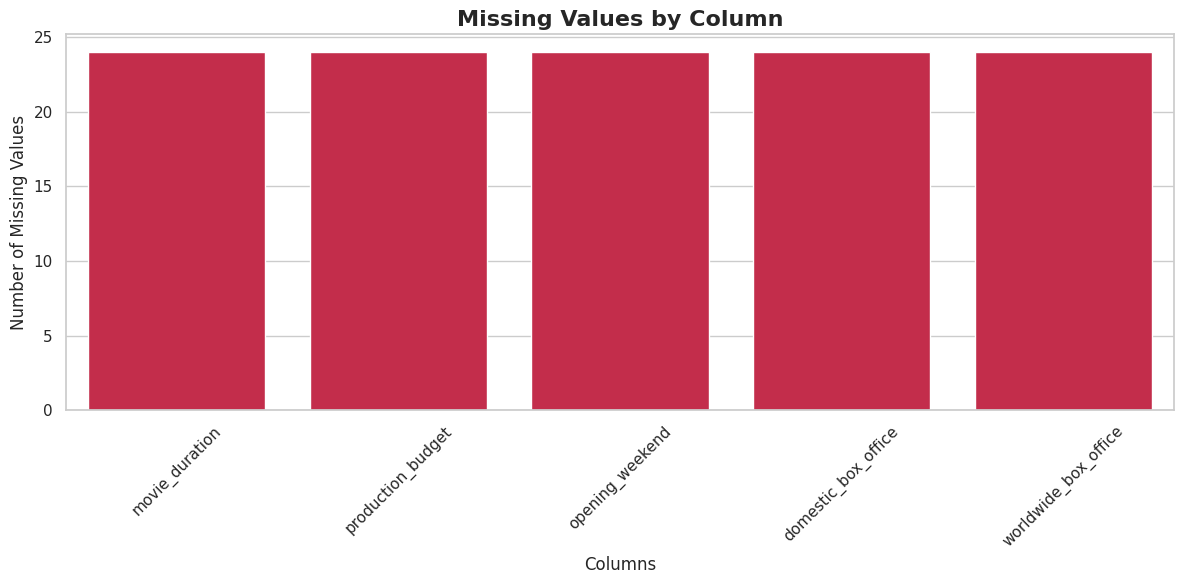

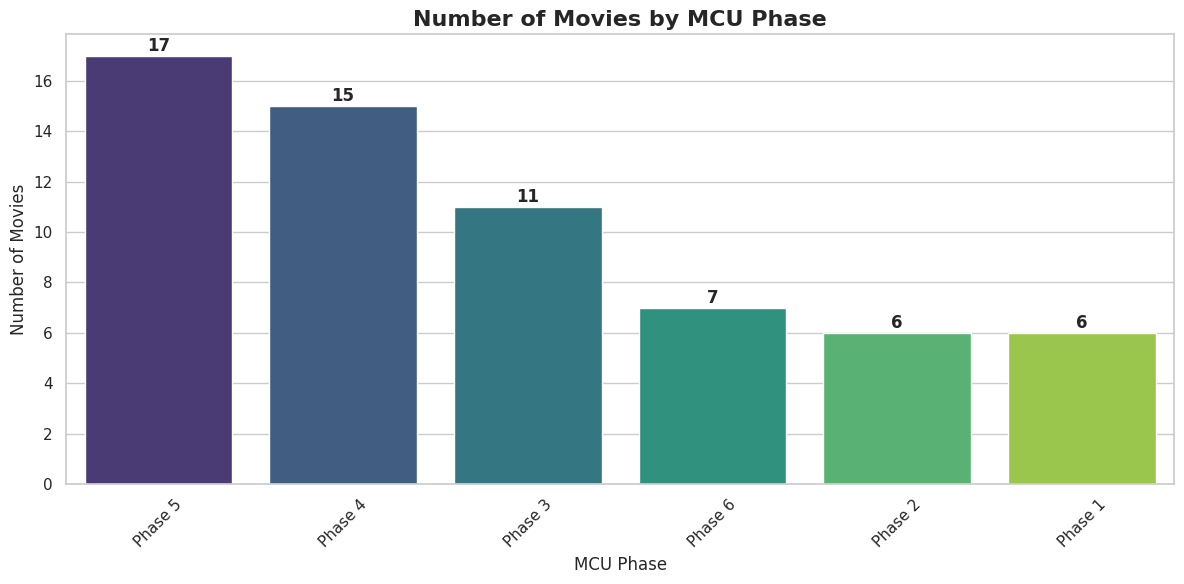

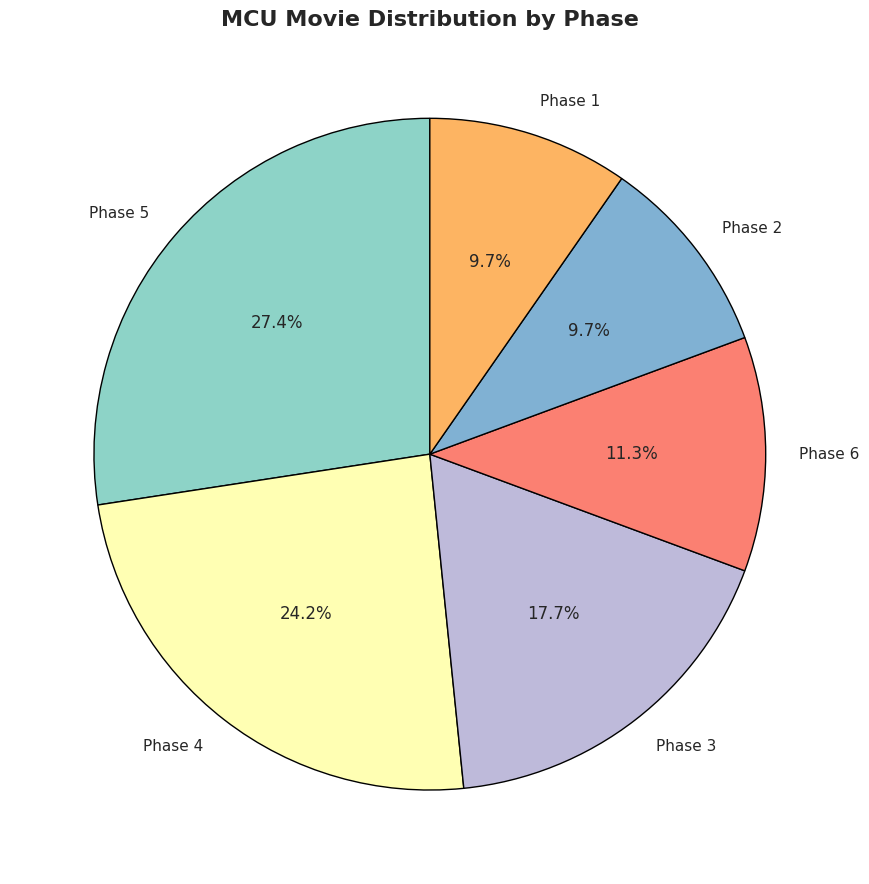

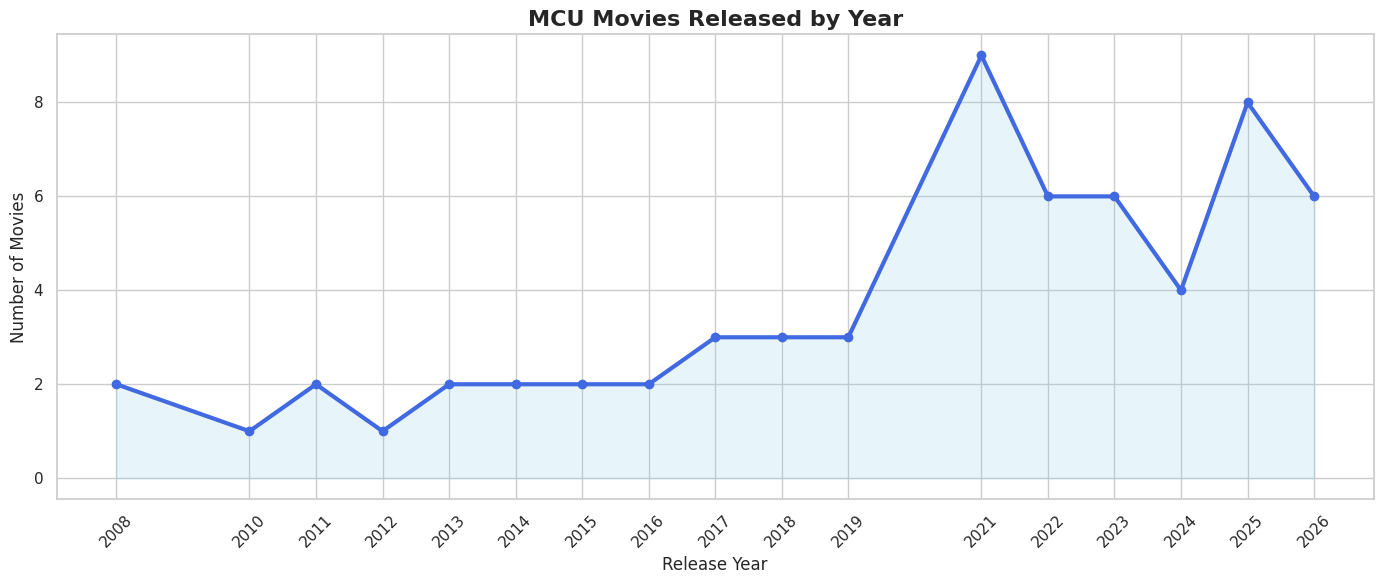

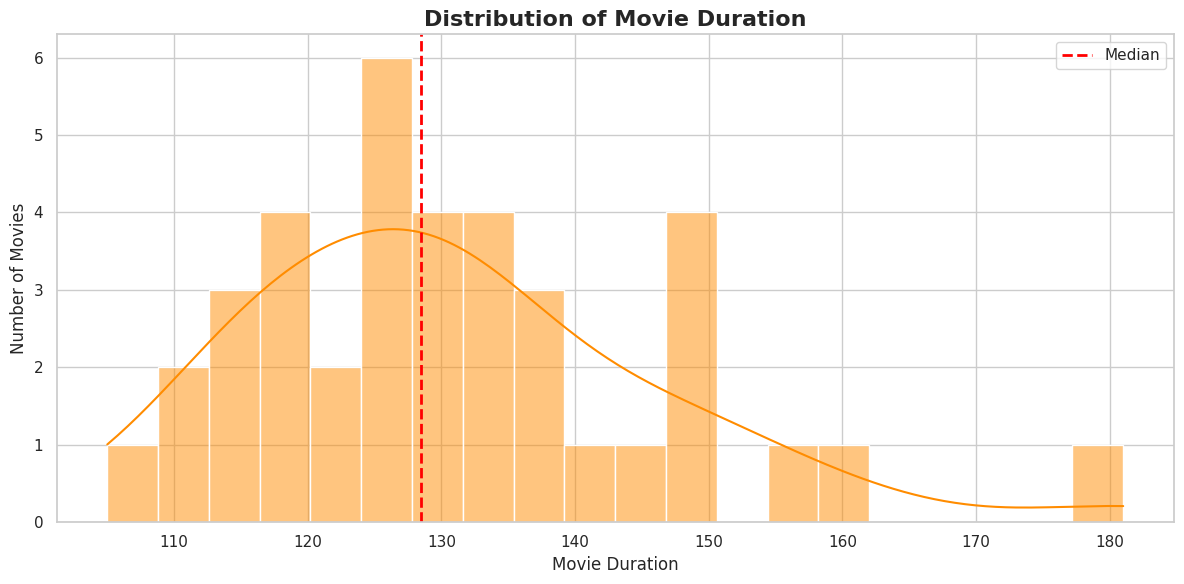

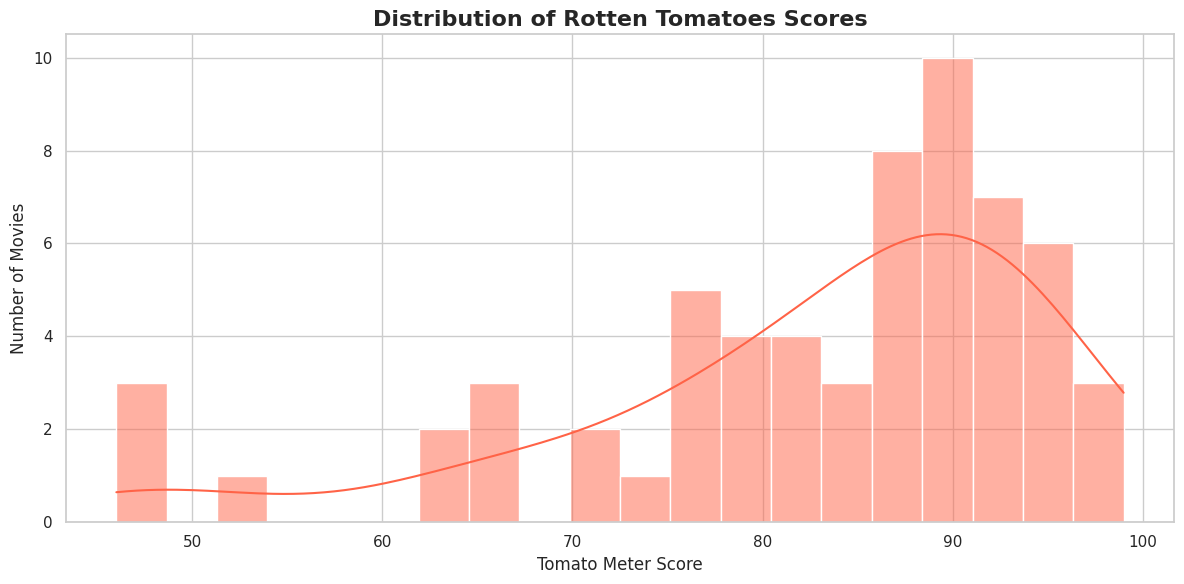

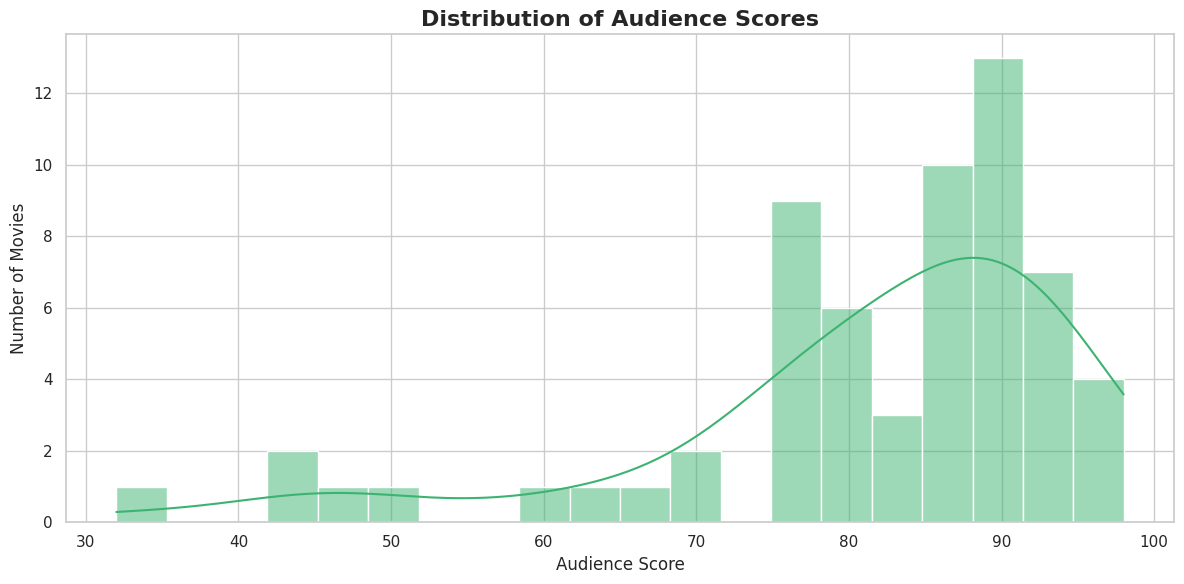

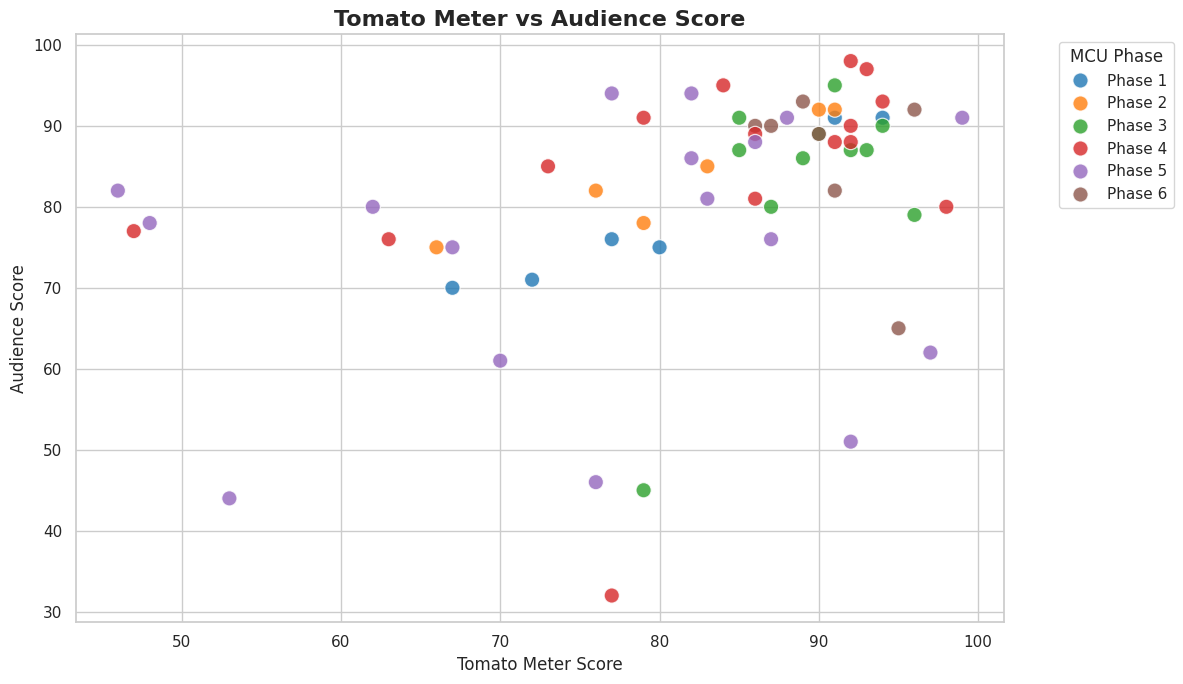

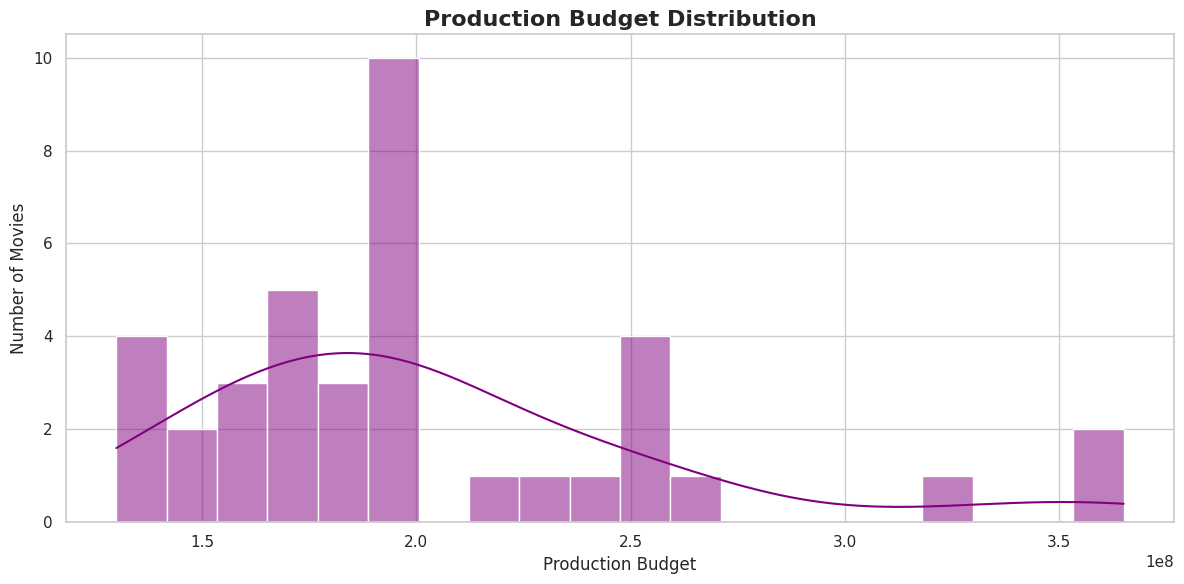

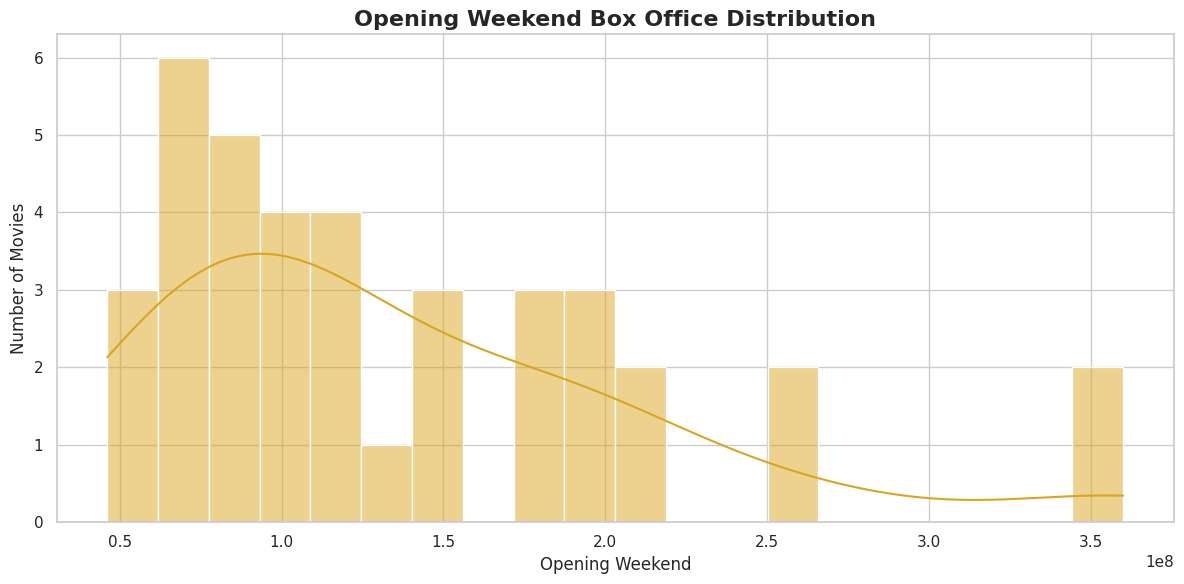

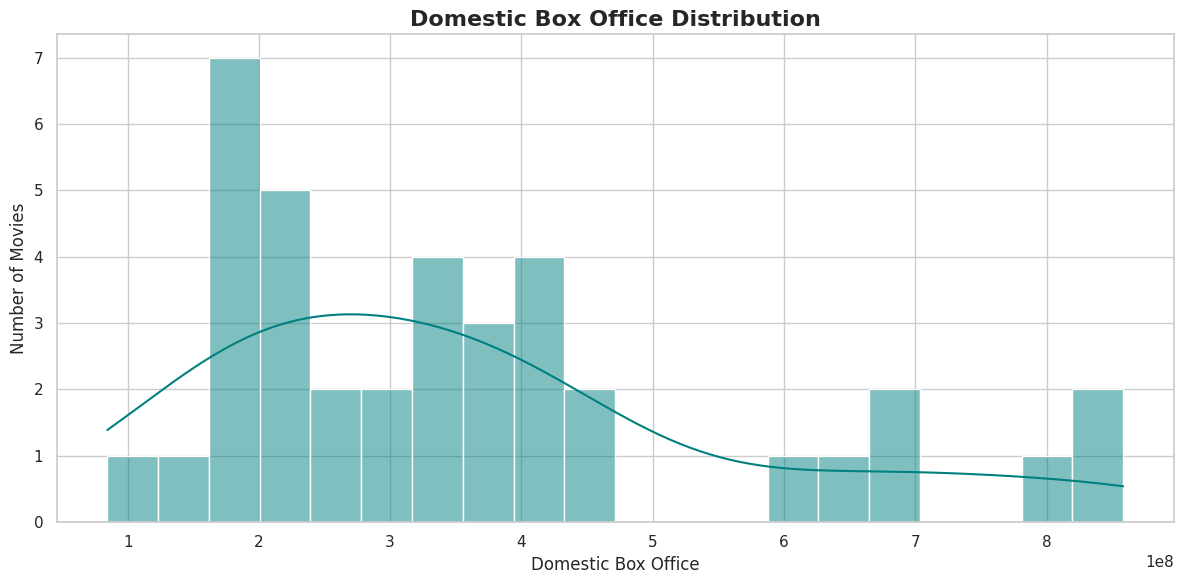

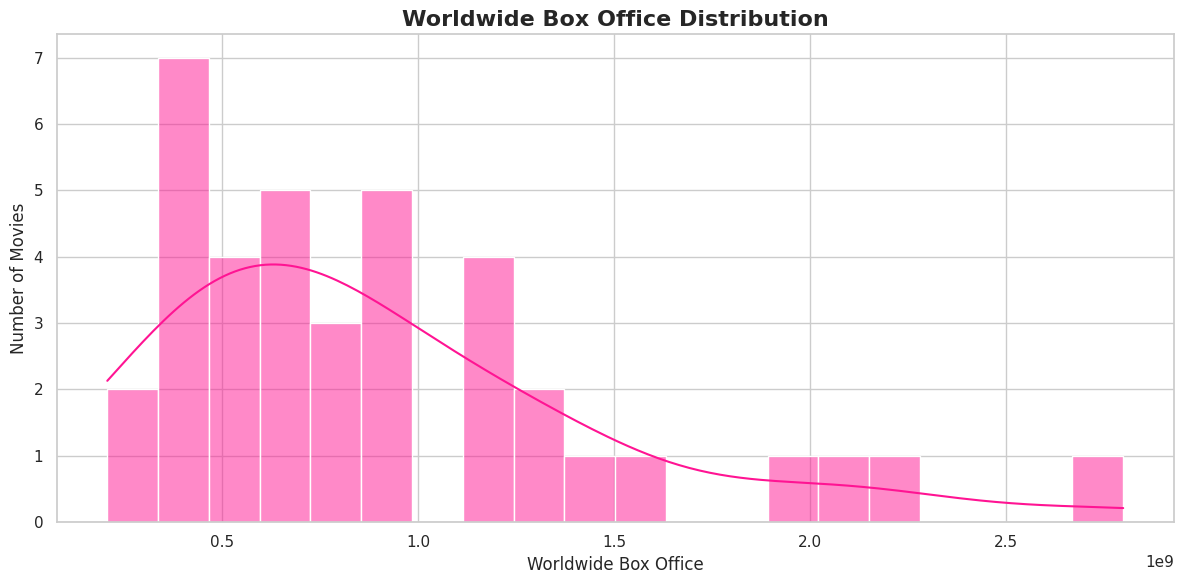

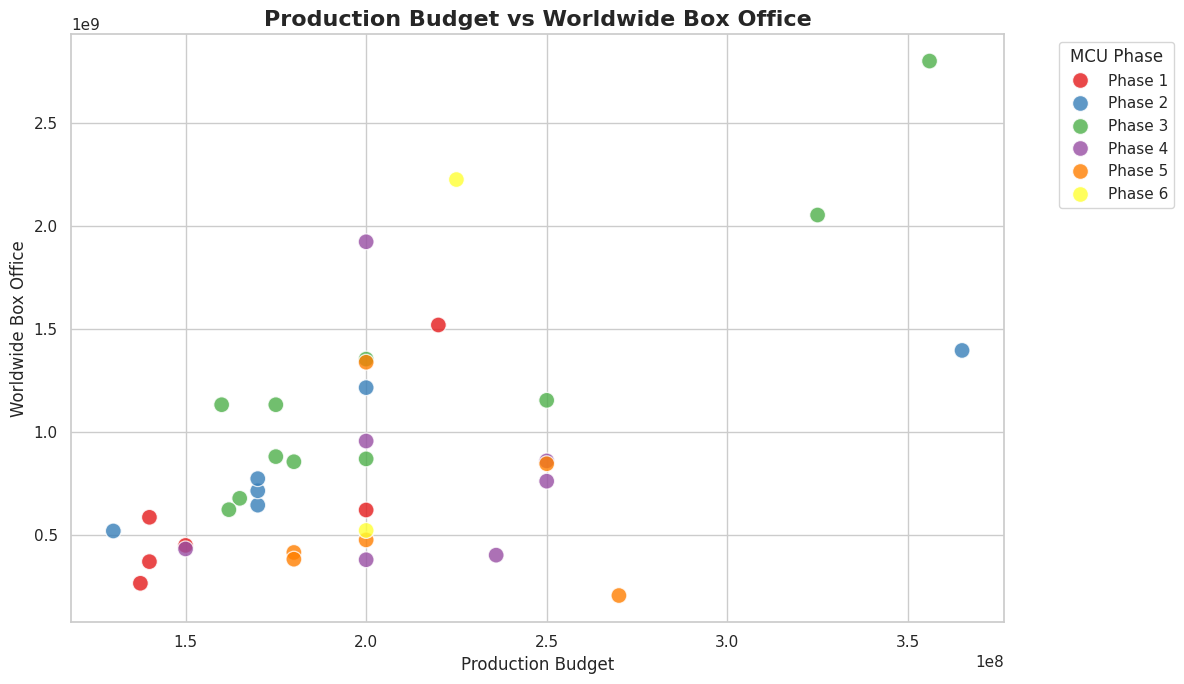

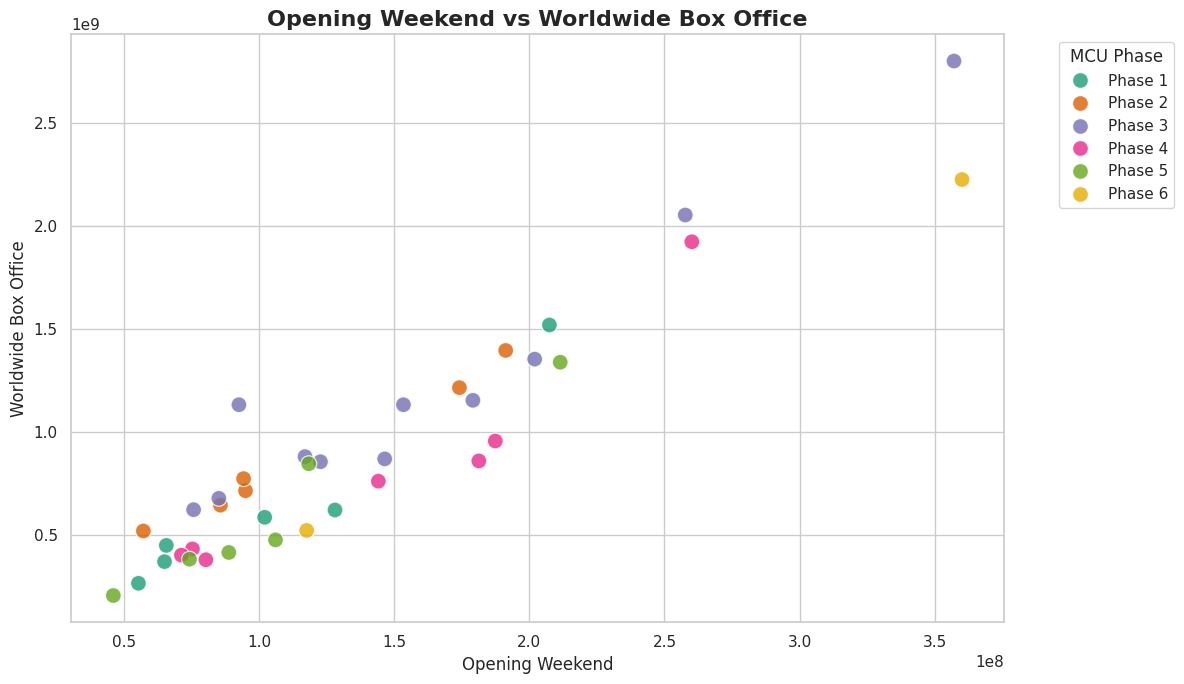

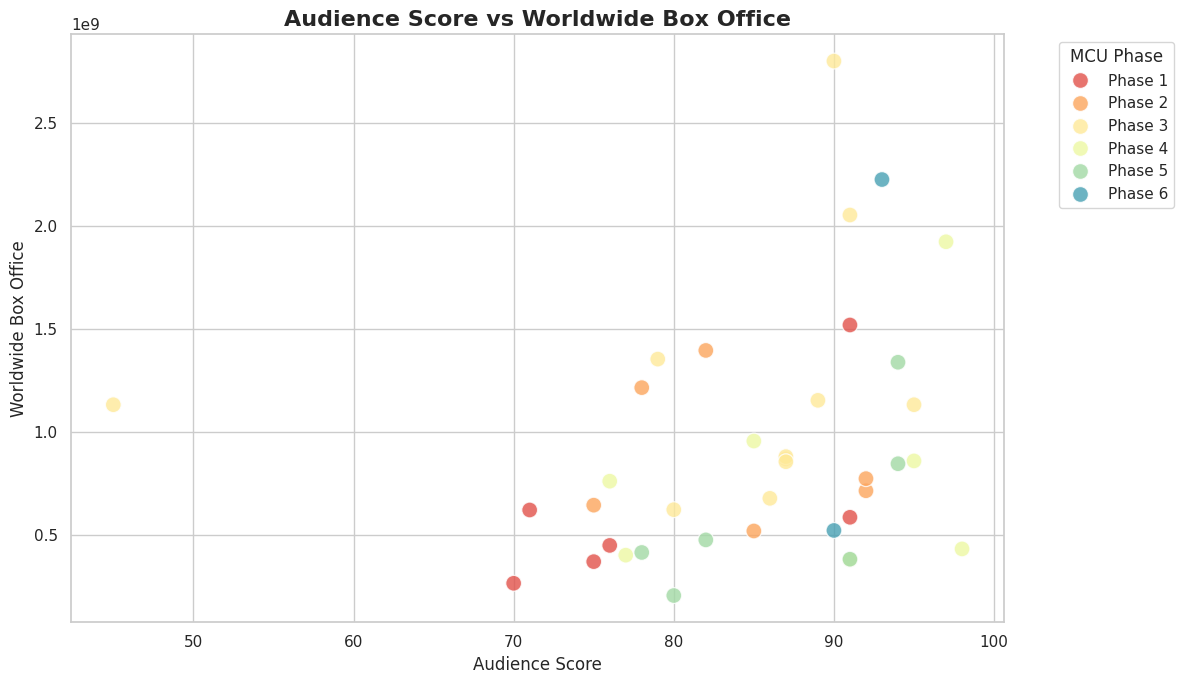

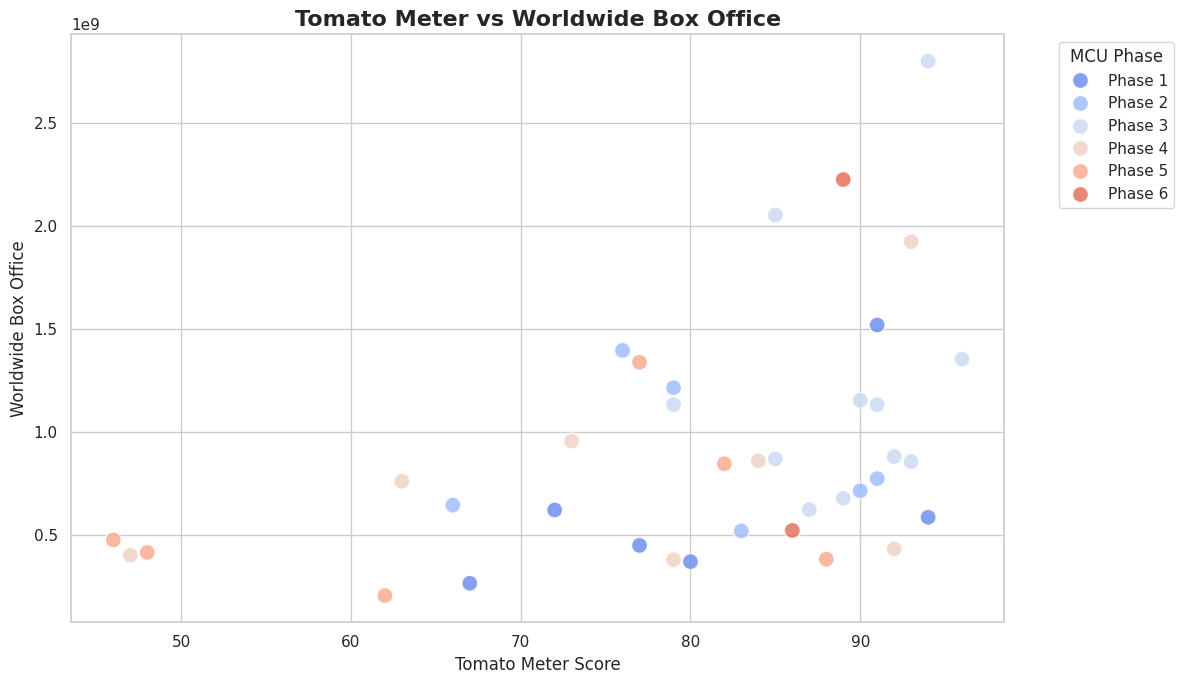

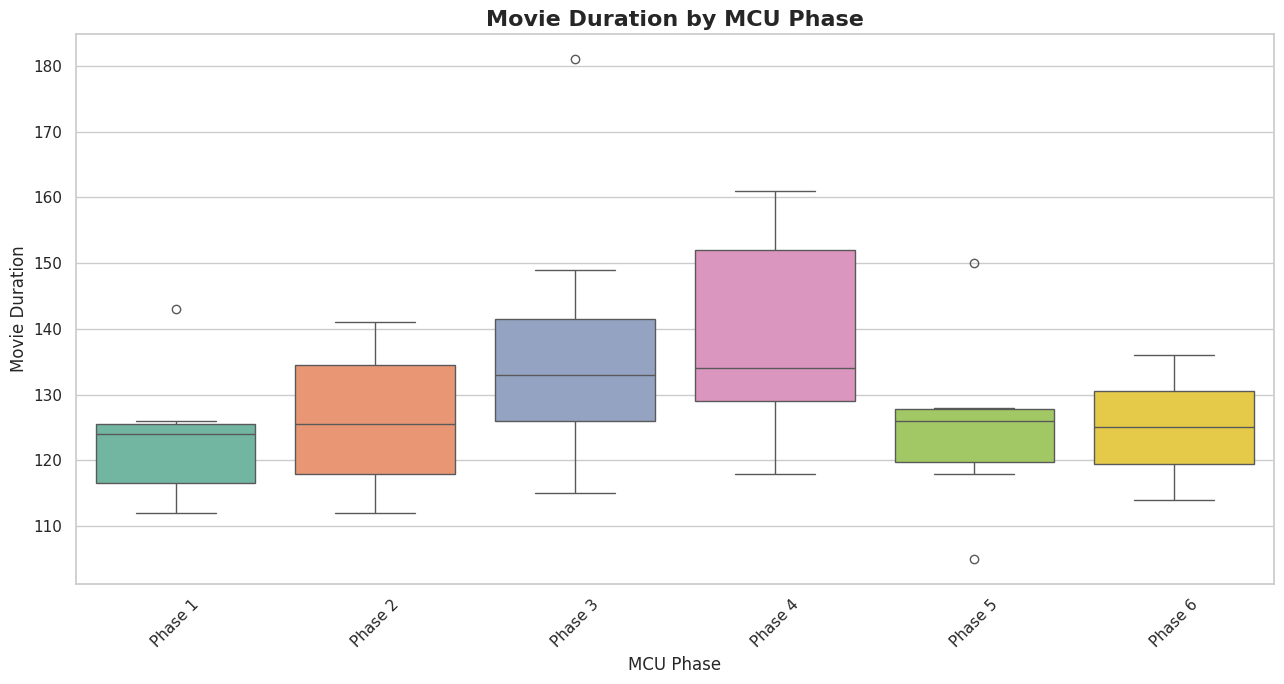

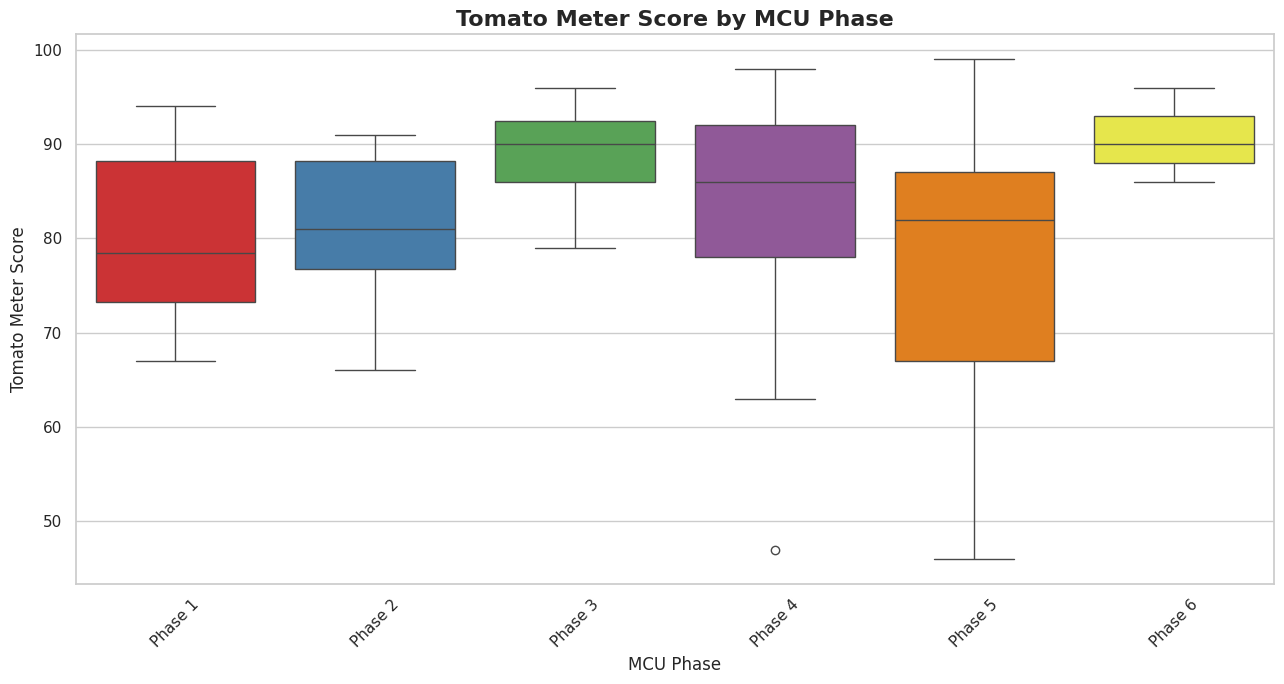

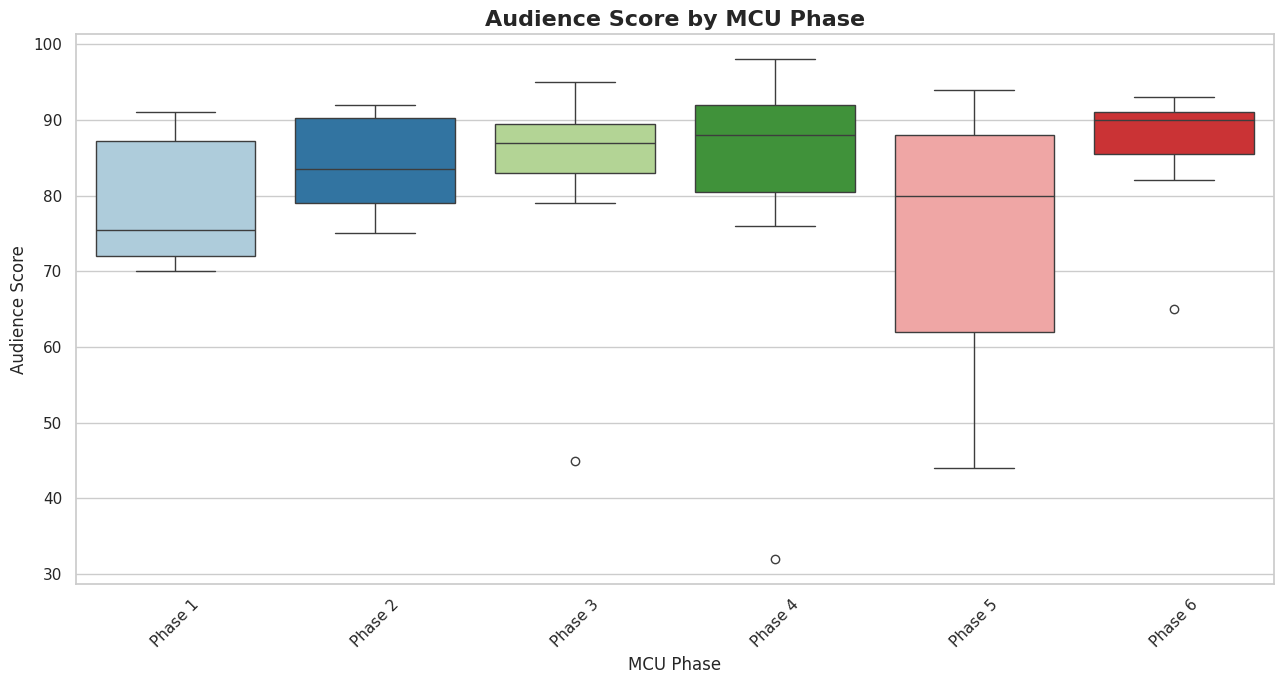

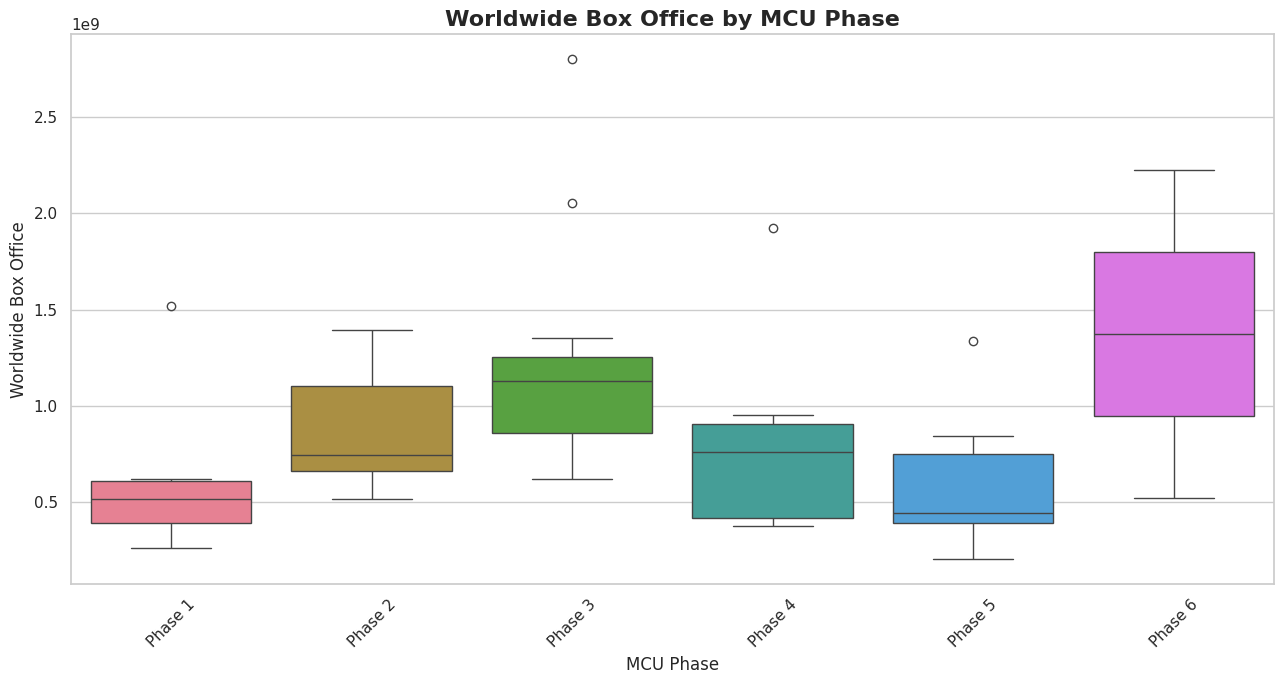

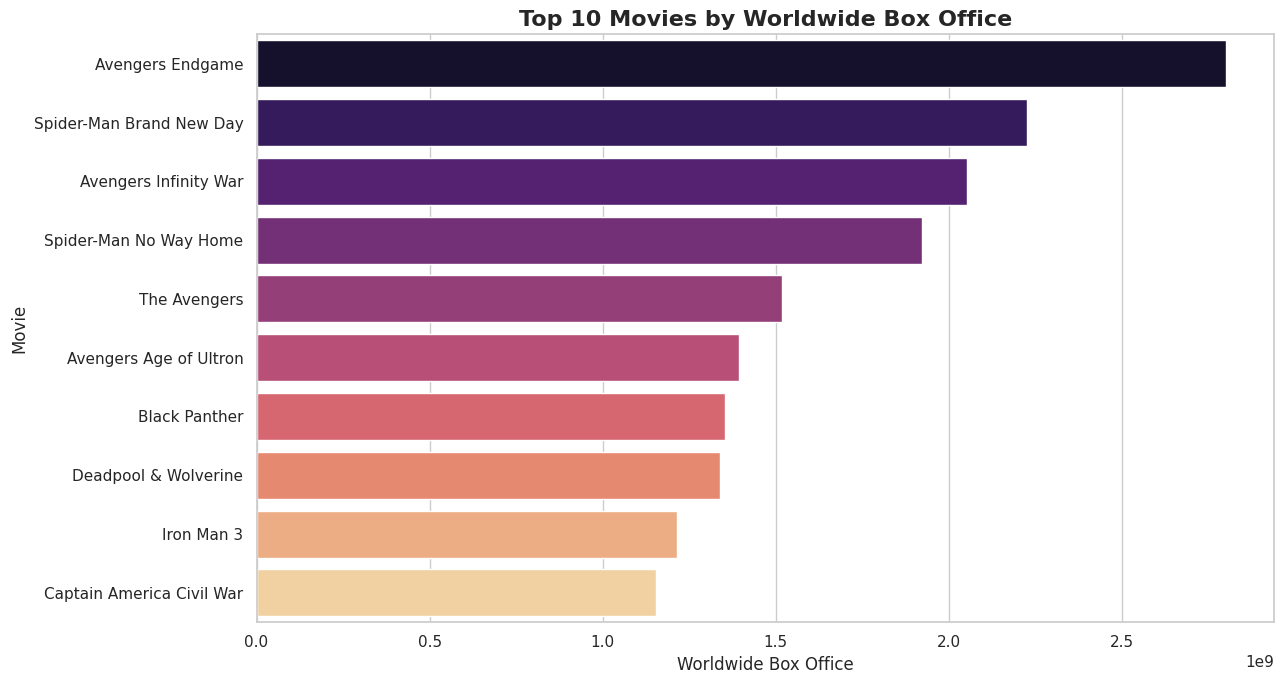

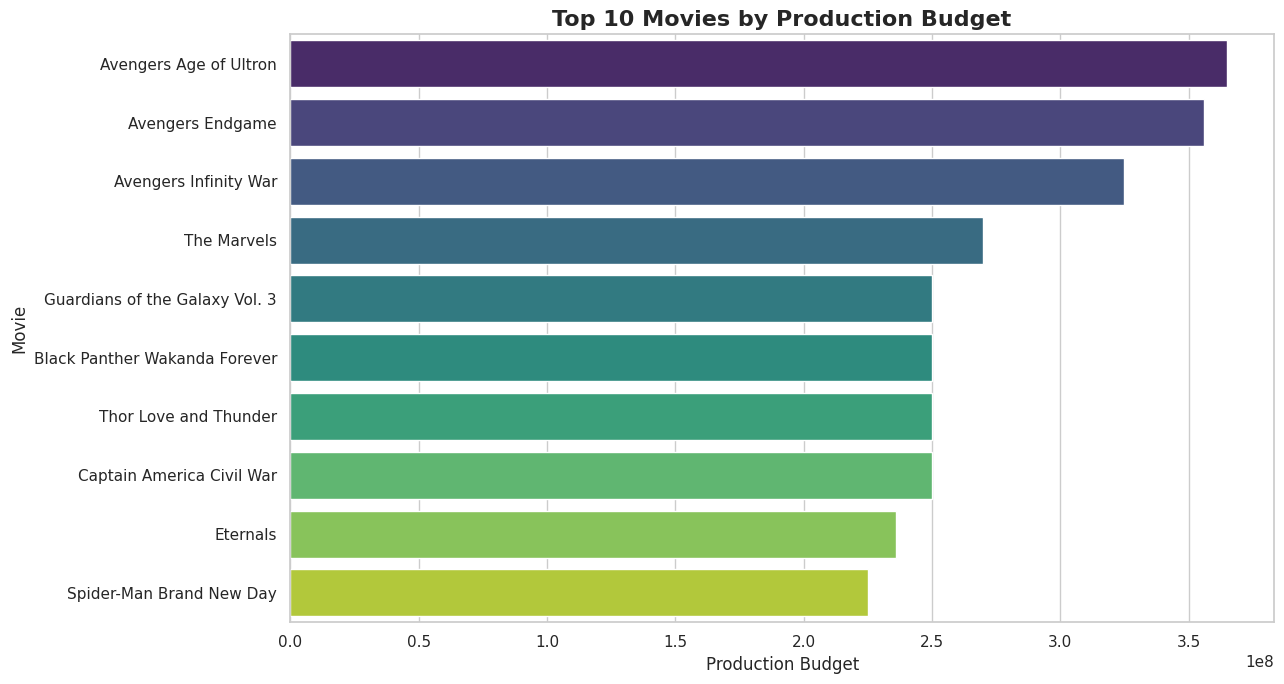

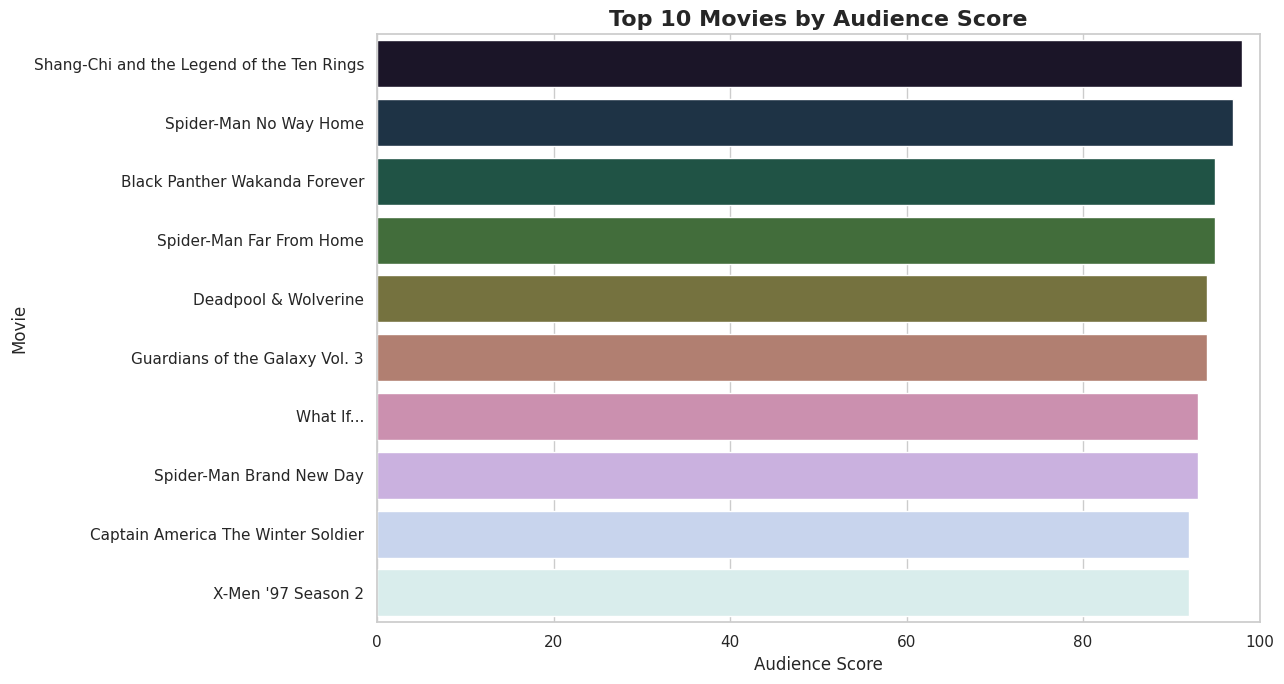

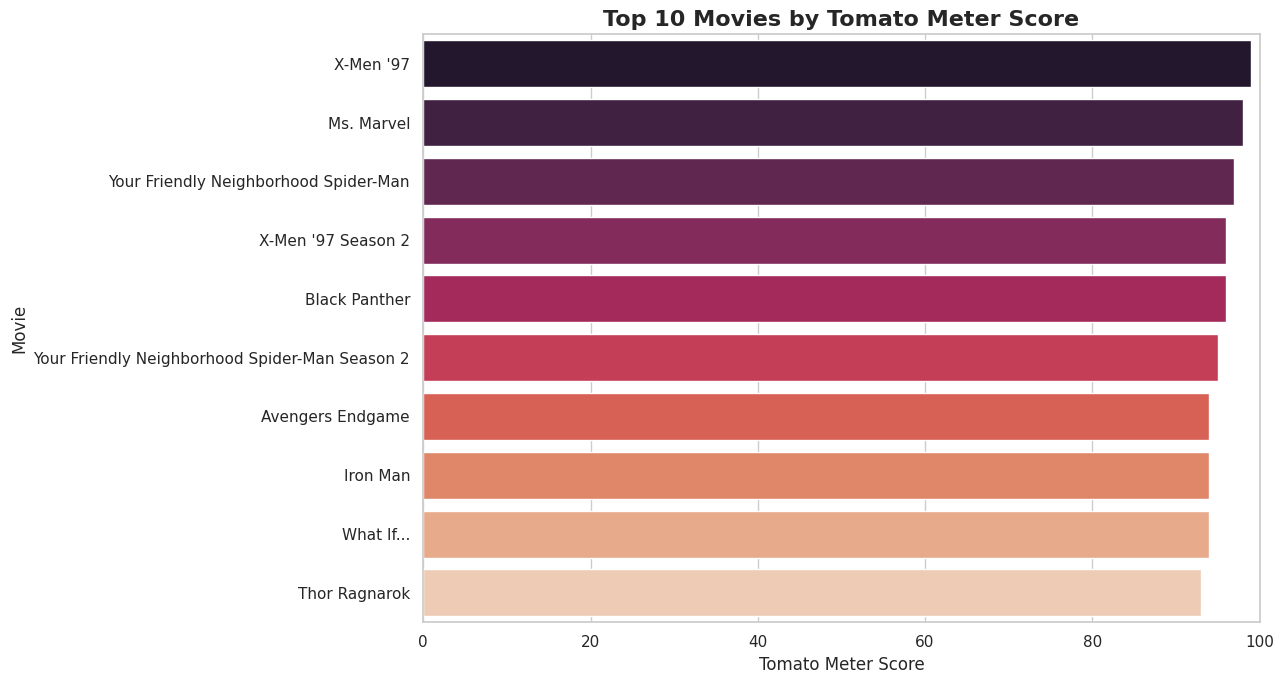

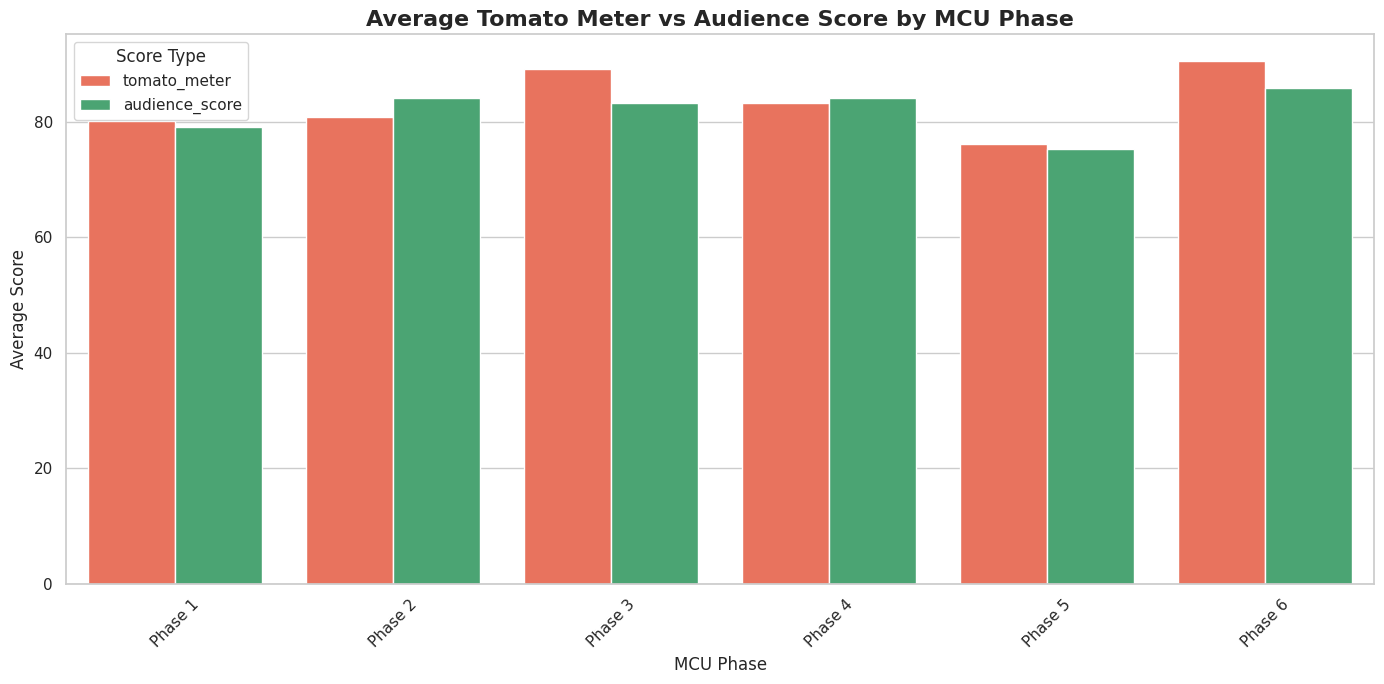

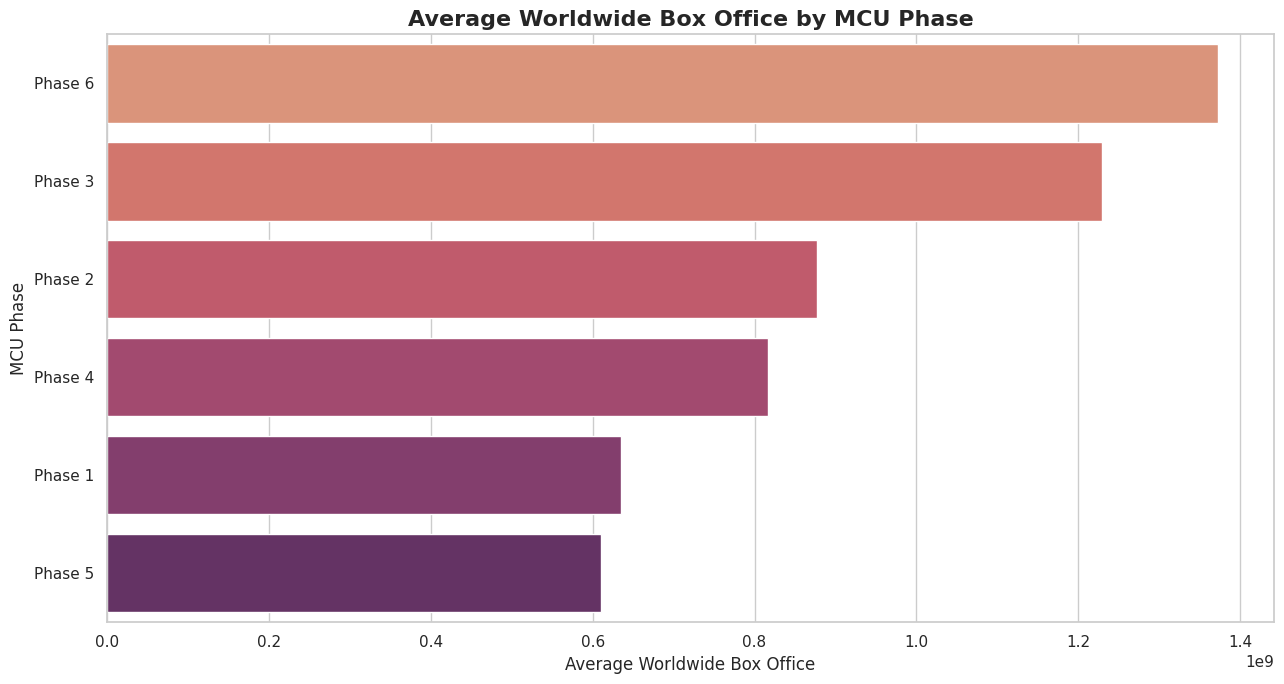

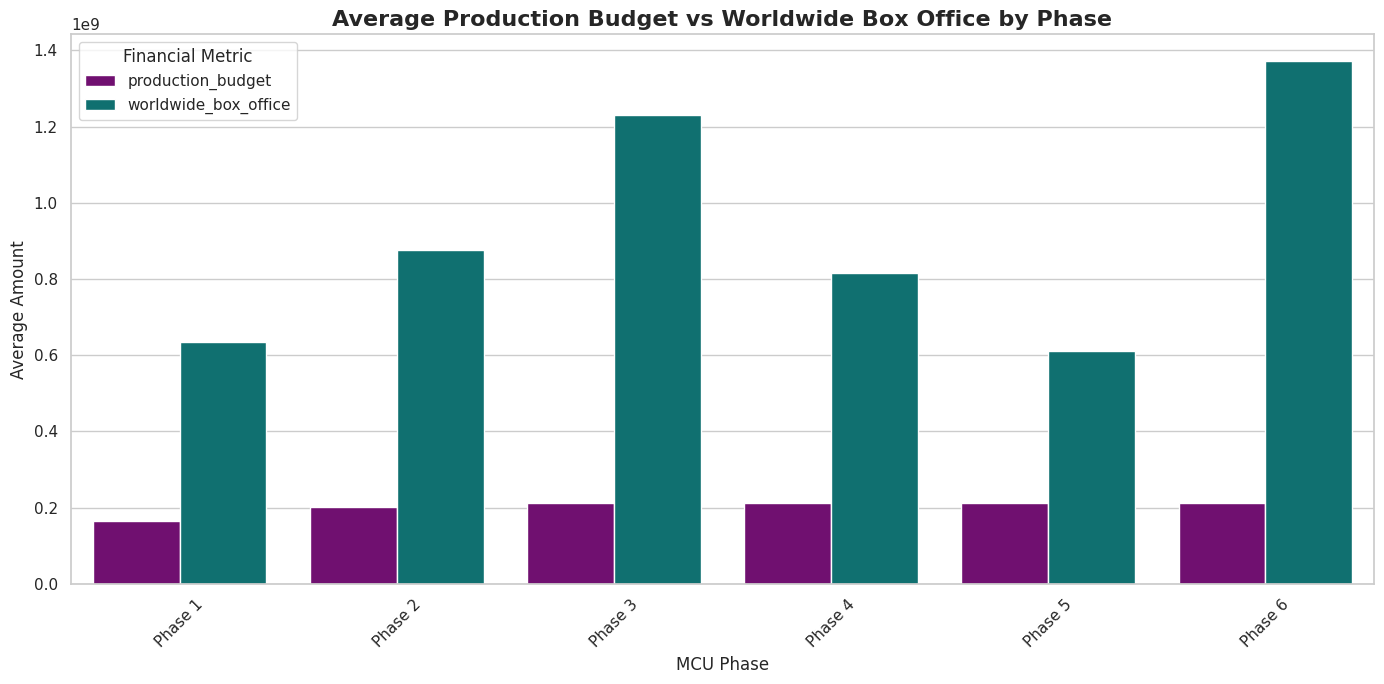

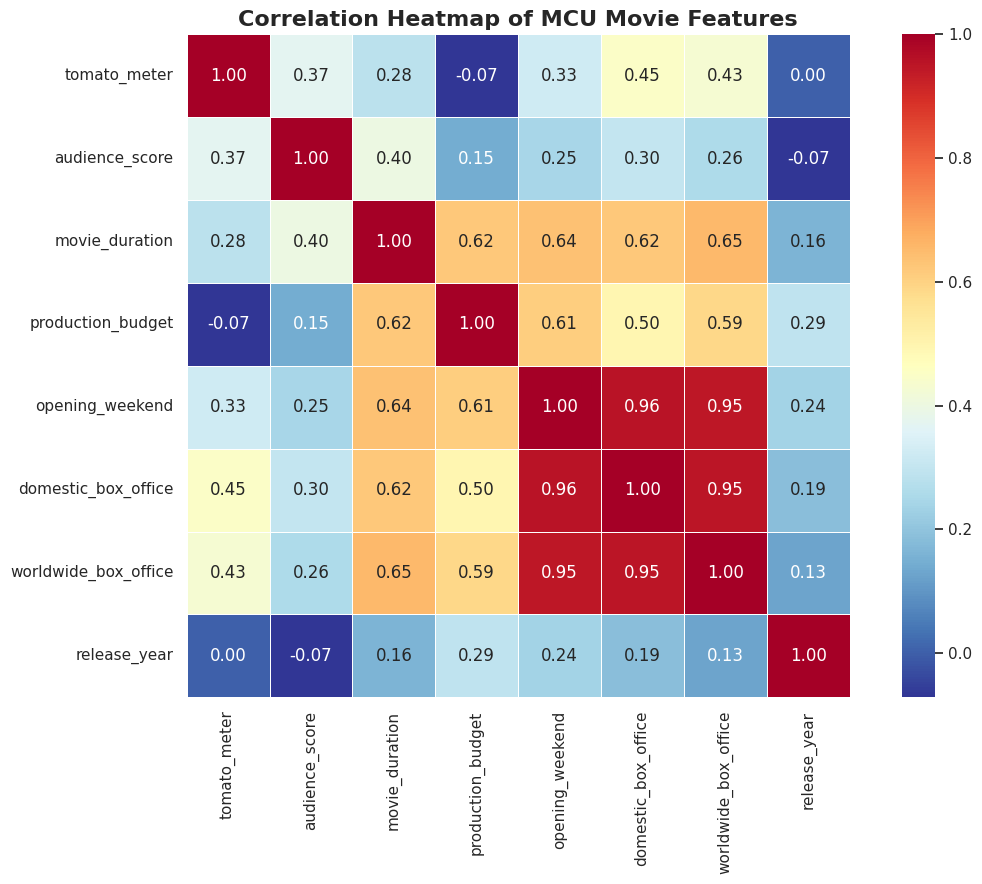

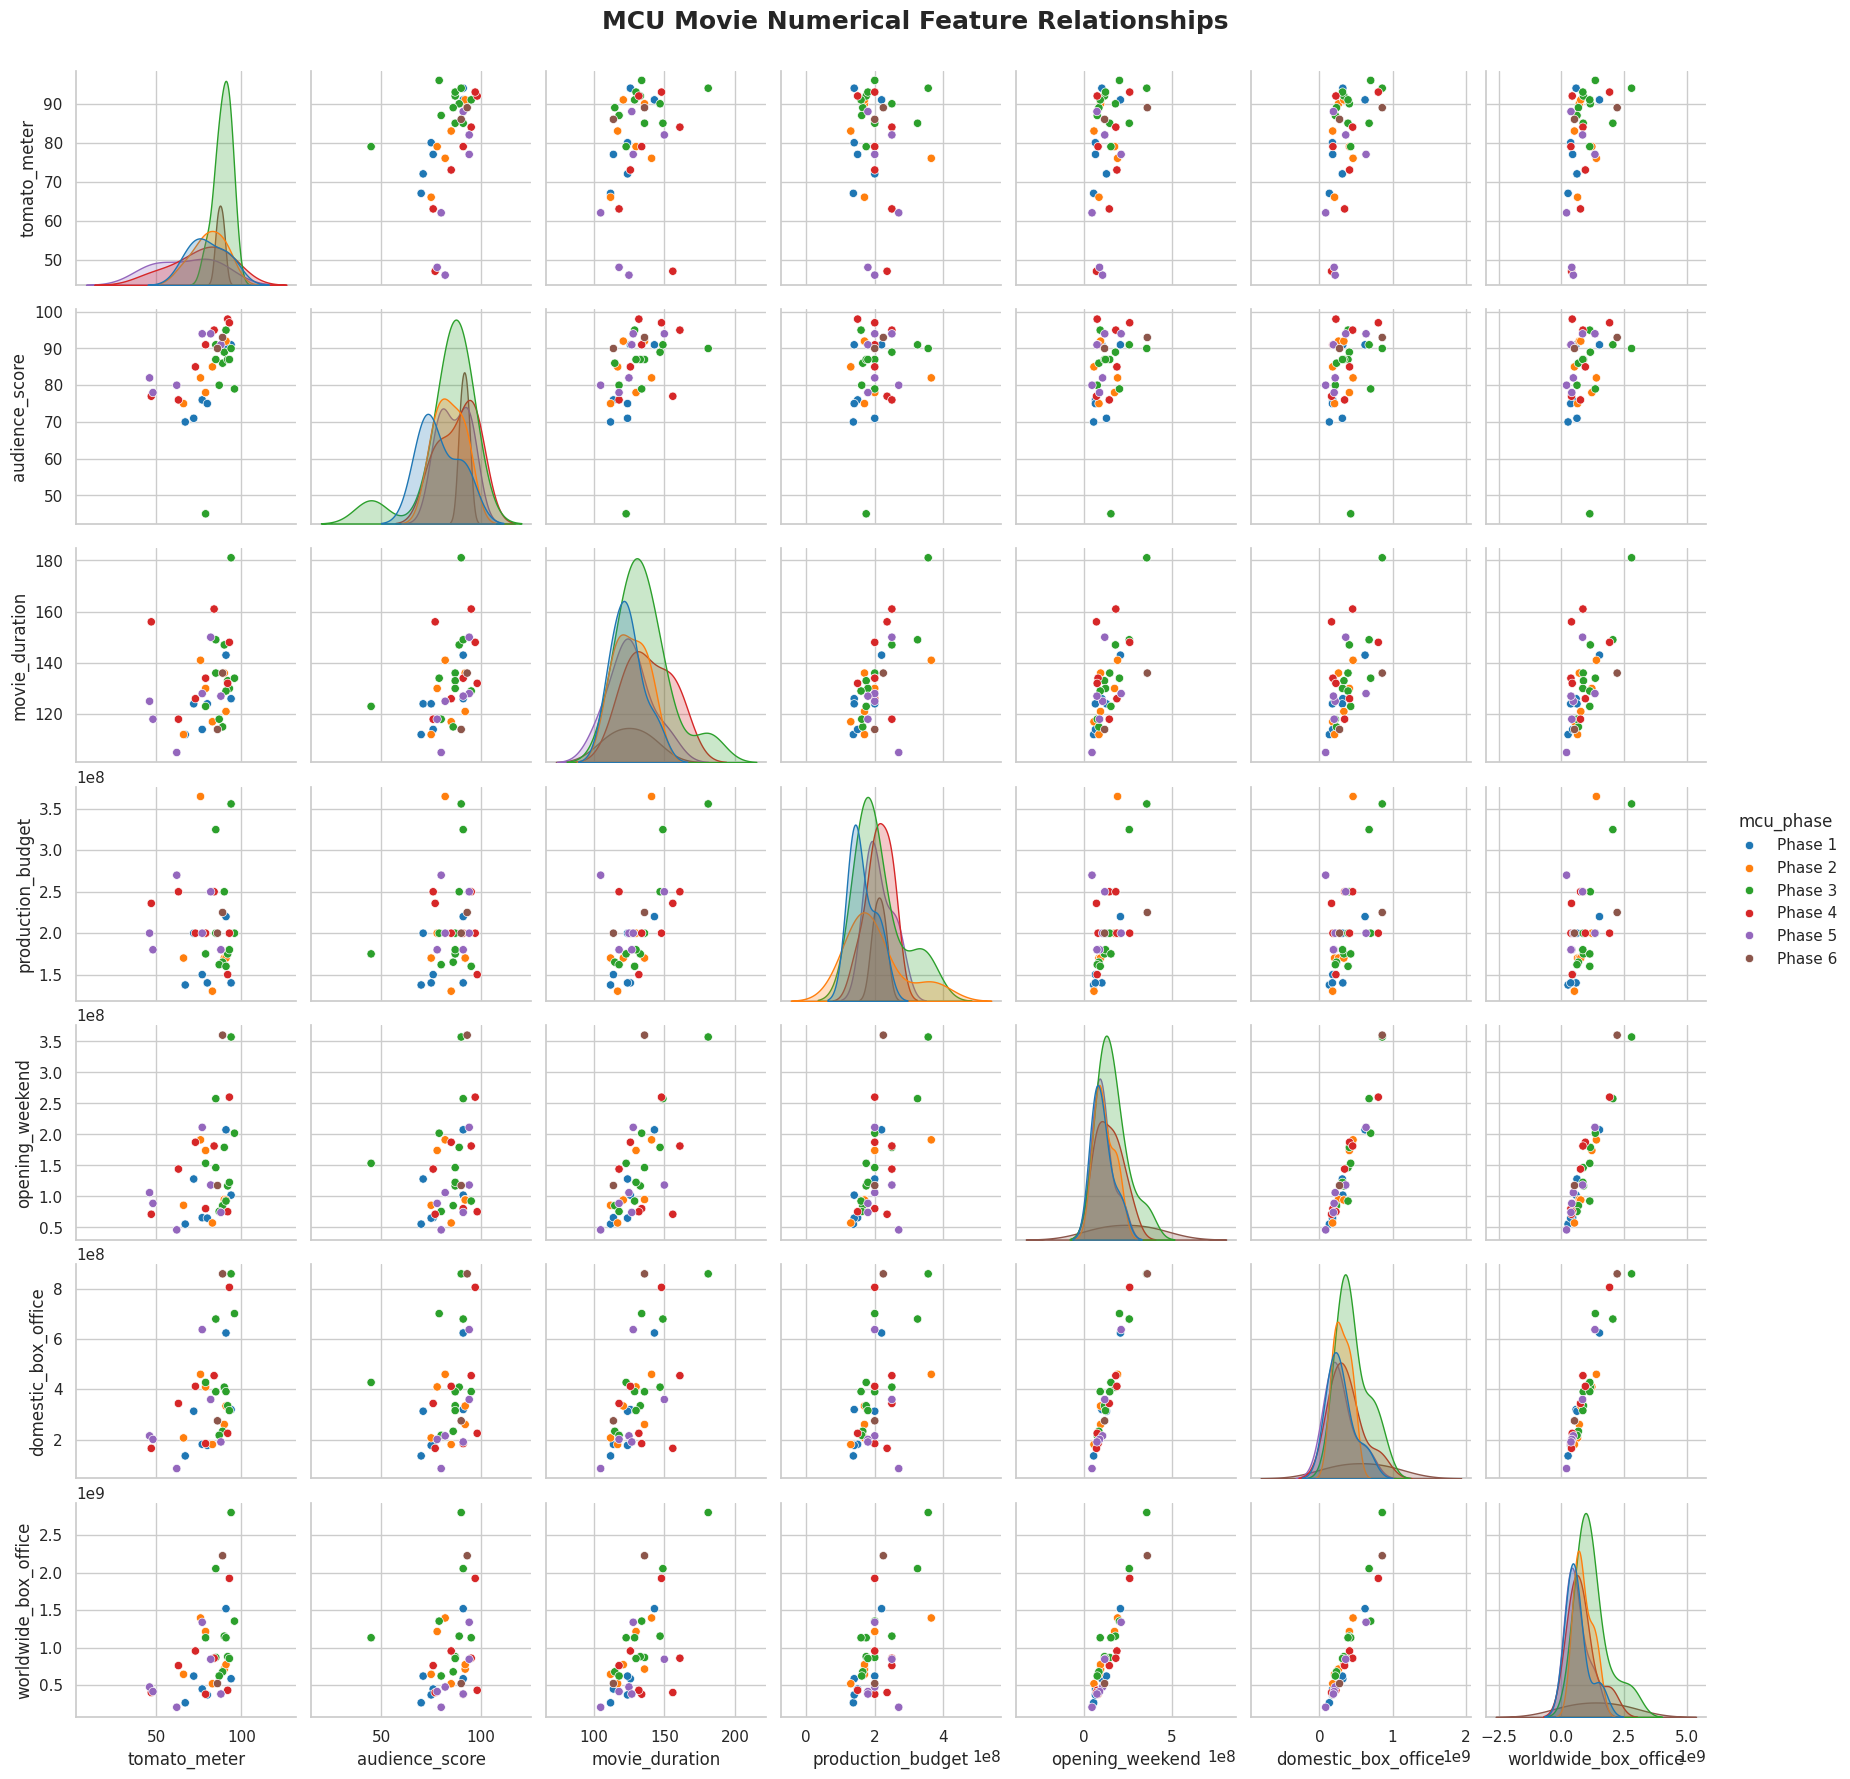

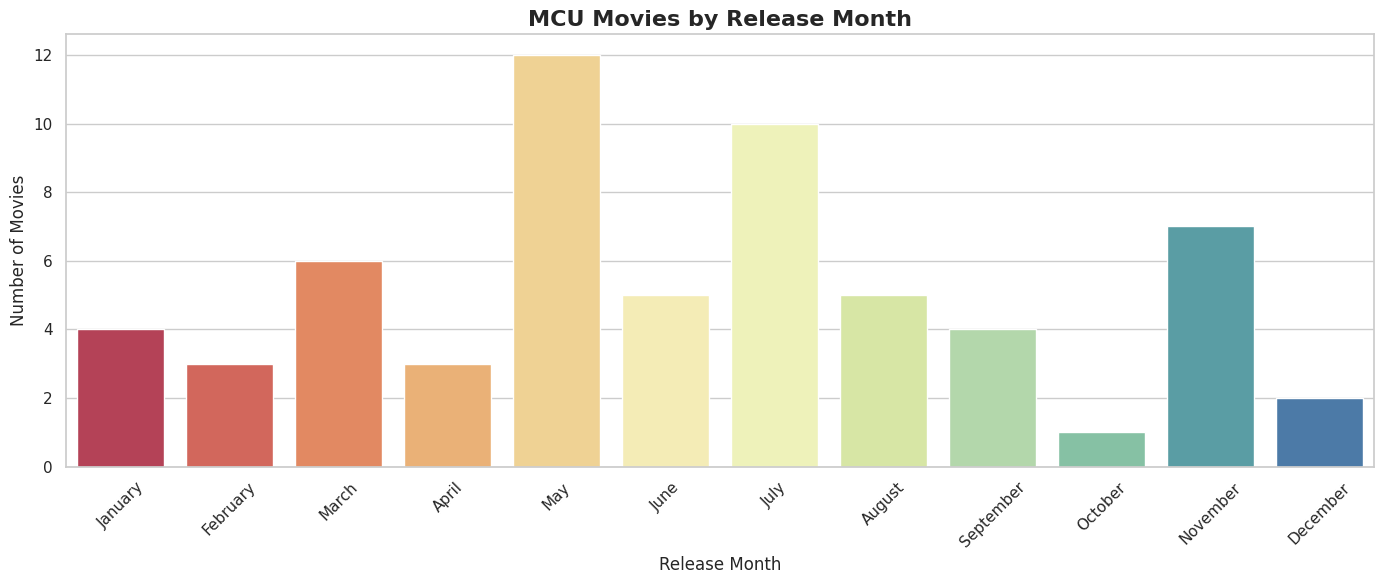

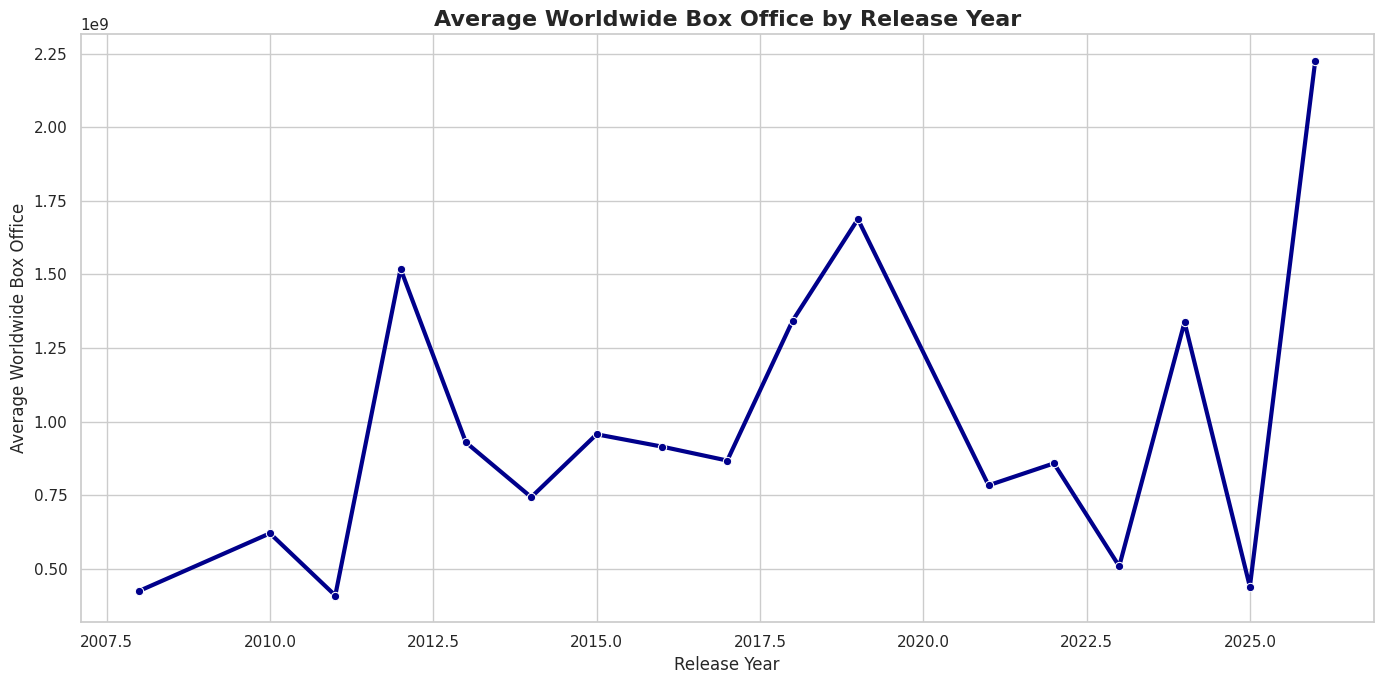

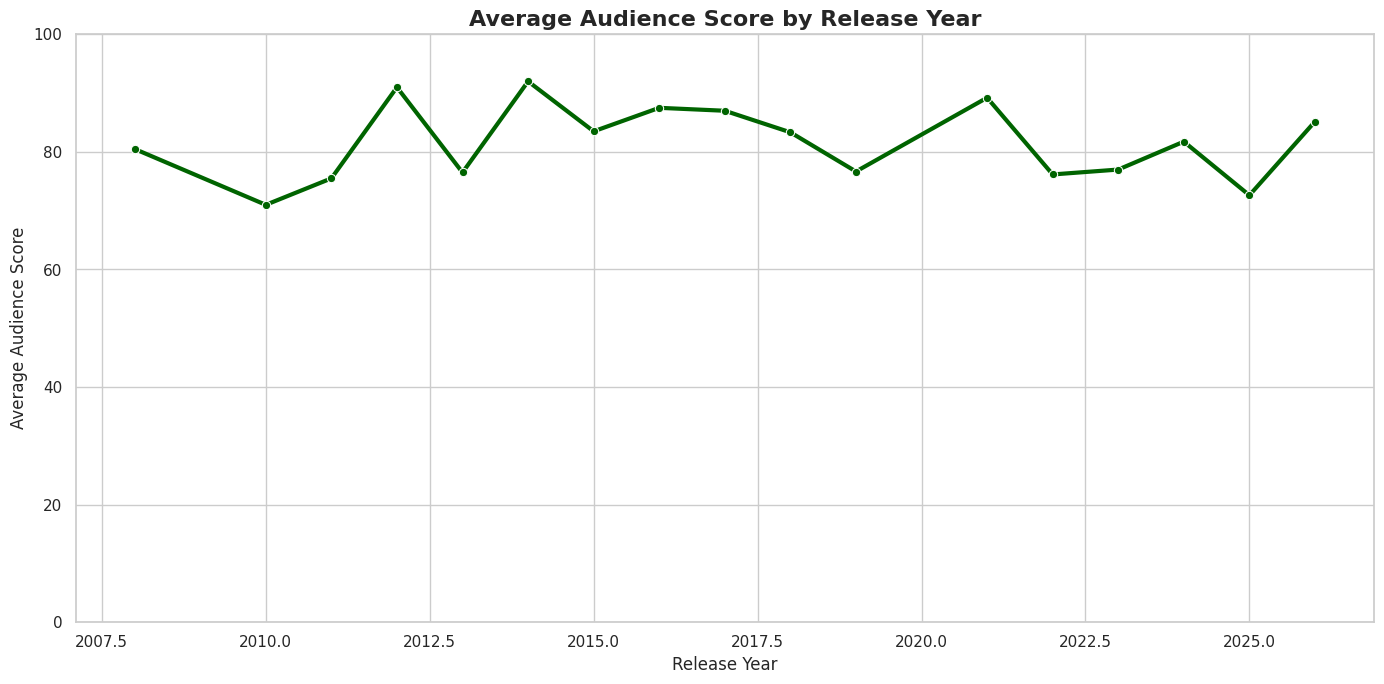


FINAL DATA SUMMARY

Number of Movies: 62

Average Tomato Meter: 82.63
Average Audience Score: 81.21
Average Movie Duration: 130.87
Average Production Budget: 203460526.32
Average Opening Weekend: 137733534.84
Average Domestic Box Office: 367125087.71
Average Worldwide Box Office: 913754990.0

Visualization Completed Successfully!


In [14]:
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Seaborn style
sns.set_style("whitegrid")

# ============================================================
# 2. LOAD DATASET
# ============================================================



print("=" * 80)
print("MCU MOVIES DATASET")
print("=" * 80)

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())

# ============================================================
# 3. DATA INFORMATION
# ============================================================

print("\n" + "=" * 80)
print("DATA INFORMATION")
print("=" * 80)

print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
print(df.describe(include="all").T)

# ============================================================
# 4. DATA CLEANING
# ============================================================

# Convert release date
df["release_date"] = pd.to_datetime(
    df["release_date"],
    errors="coerce"
)

# Create date-related columns
df["release_year"] = df["release_date"].dt.year
df["release_month"] = df["release_date"].dt.month
df["release_month_name"] = df["release_date"].dt.month_name()

# Remove duplicate rows
df = df.drop_duplicates().copy()

# ============================================================
# 5. MISSING VALUES VISUALIZATION
# ============================================================

missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) > 0:

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x=missing.index,
        y=missing.values,
        color="crimson"
    )

    plt.title(
        "Missing Values by Column",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# ============================================================
# 6. MCU PHASE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

phase_counts = df["mcu_phase"].value_counts()

sns.barplot(
    x=phase_counts.index,
    y=phase_counts.values,
    palette="viridis"
)

plt.title(
    "Number of Movies by MCU Phase",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("MCU Phase")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45)

for i, value in enumerate(phase_counts.values):
    plt.text(
        i,
        value + 0.2,
        str(value),
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

# ============================================================
# 7. MCU PHASE PIE CHART
# ============================================================

plt.figure(figsize=(9, 9))

phase_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set3", len(phase_counts)),
    wedgeprops={"edgecolor": "black"}
)

plt.title(
    "MCU Movie Distribution by Phase",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("")

plt.tight_layout()
plt.show()

# ============================================================
# 8. MOVIES RELEASED BY YEAR
# ============================================================

year_counts = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(14, 6))

plt.plot(
    year_counts.index,
    year_counts.values,
    marker="o",
    linewidth=3,
    color="royalblue"
)

plt.fill_between(
    year_counts.index,
    year_counts.values,
    alpha=0.2,
    color="skyblue"
)

plt.title(
    "MCU Movies Released by Year",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Release Year")
plt.ylabel("Number of Movies")

plt.xticks(
    year_counts.index,
    rotation=45
)

plt.tight_layout()
plt.show()

# ============================================================
# 9. MOVIE DURATION DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

sns.histplot(
    df["movie_duration"].dropna(),
    bins=20,
    kde=True,
    color="darkorange"
)

plt.axvline(
    df["movie_duration"].median(),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Median"
)

plt.title(
    "Distribution of Movie Duration",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Movie Duration")
plt.ylabel("Number of Movies")

plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# 10. TOMATOMETER SCORE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

sns.histplot(
    df["tomato_meter"].dropna(),
    bins=20,
    kde=True,
    color="tomato"
)

plt.title(
    "Distribution of Rotten Tomatoes Scores",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Tomato Meter Score")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

# ============================================================
# 11. AUDIENCE SCORE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

sns.histplot(
    df["audience_score"].dropna(),
    bins=20,
    kde=True,
    color="mediumseagreen"
)

plt.title(
    "Distribution of Audience Scores",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Audience Score")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

# ============================================================
# 12. TOMATOMETER VS AUDIENCE SCORE
# ============================================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="tomato_meter",
    y="audience_score",
    hue="mcu_phase",
    palette="tab10",
    s=120,
    alpha=0.8
)

plt.title(
    "Tomato Meter vs Audience Score",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Tomato Meter Score")
plt.ylabel("Audience Score")

plt.legend(
    title="MCU Phase",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 13. PRODUCTION BUDGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

sns.histplot(
    df["production_budget"].dropna(),
    bins=20,
    kde=True,
    color="purple"
)

plt.title(
    "Production Budget Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Production Budget")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

# ============================================================
# 14. OPENING WEEKEND DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

sns.histplot(
    df["opening_weekend"].dropna(),
    bins=20,
    kde=True,
    color="goldenrod"
)

plt.title(
    "Opening Weekend Box Office Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Opening Weekend")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

# ============================================================
# 15. DOMESTIC BOX OFFICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

sns.histplot(
    df["domestic_box_office"].dropna(),
    bins=20,
    kde=True,
    color="teal"
)

plt.title(
    "Domestic Box Office Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Domestic Box Office")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

# ============================================================
# 16. WORLDWIDE BOX OFFICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

sns.histplot(
    df["worldwide_box_office"].dropna(),
    bins=20,
    kde=True,
    color="deeppink"
)

plt.title(
    "Worldwide Box Office Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Worldwide Box Office")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

# ============================================================
# 17. PRODUCTION BUDGET VS WORLDWIDE BOX OFFICE
# ============================================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="production_budget",
    y="worldwide_box_office",
    hue="mcu_phase",
    palette="Set1",
    s=130,
    alpha=0.8
)

plt.title(
    "Production Budget vs Worldwide Box Office",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Production Budget")
plt.ylabel("Worldwide Box Office")

plt.legend(
    title="MCU Phase",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 18. OPENING WEEKEND VS WORLDWIDE BOX OFFICE
# ============================================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="opening_weekend",
    y="worldwide_box_office",
    hue="mcu_phase",
    palette="Dark2",
    s=130,
    alpha=0.8
)

plt.title(
    "Opening Weekend vs Worldwide Box Office",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Opening Weekend")
plt.ylabel("Worldwide Box Office")

plt.legend(
    title="MCU Phase",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 19. AUDIENCE SCORE VS WORLDWIDE BOX OFFICE
# ============================================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="audience_score",
    y="worldwide_box_office",
    hue="mcu_phase",
    palette="Spectral",
    s=130,
    alpha=0.8
)

plt.title(
    "Audience Score vs Worldwide Box Office",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Audience Score")
plt.ylabel("Worldwide Box Office")

plt.legend(
    title="MCU Phase",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 20. TOMATO METER VS WORLDWIDE BOX OFFICE
# ============================================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="tomato_meter",
    y="worldwide_box_office",
    hue="mcu_phase",
    palette="coolwarm",
    s=130,
    alpha=0.8
)

plt.title(
    "Tomato Meter vs Worldwide Box Office",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Tomato Meter Score")
plt.ylabel("Worldwide Box Office")

plt.legend(
    title="MCU Phase",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 21. MOVIE DURATION BY MCU PHASE
# ============================================================

plt.figure(figsize=(13, 7))

sns.boxplot(
    data=df,
    x="mcu_phase",
    y="movie_duration",
    palette="Set2"
)

plt.title(
    "Movie Duration by MCU Phase",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("MCU Phase")
plt.ylabel("Movie Duration")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ============================================================
# 22. TOMATO METER BY MCU PHASE
# ============================================================

plt.figure(figsize=(13, 7))

sns.boxplot(
    data=df,
    x="mcu_phase",
    y="tomato_meter",
    palette="Set1"
)

plt.title(
    "Tomato Meter Score by MCU Phase",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("MCU Phase")
plt.ylabel("Tomato Meter Score")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ============================================================
# 23. AUDIENCE SCORE BY MCU PHASE
# ============================================================

plt.figure(figsize=(13, 7))

sns.boxplot(
    data=df,
    x="mcu_phase",
    y="audience_score",
    palette="Paired"
)

plt.title(
    "Audience Score by MCU Phase",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("MCU Phase")
plt.ylabel("Audience Score")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ============================================================
# 24. WORLDWIDE BOX OFFICE BY MCU PHASE
# ============================================================

plt.figure(figsize=(13, 7))

sns.boxplot(
    data=df,
    x="mcu_phase",
    y="worldwide_box_office",
    palette="husl"
)

plt.title(
    "Worldwide Box Office by MCU Phase",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("MCU Phase")
plt.ylabel("Worldwide Box Office")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ============================================================
# 25. TOP 10 MOVIES BY WORLDWIDE BOX OFFICE
# ============================================================

top_worldwide = (
    df.sort_values(
        "worldwide_box_office",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(13, 7))

sns.barplot(
    data=top_worldwide,
    x="worldwide_box_office",
    y="movie_title",
    palette="magma"
)

plt.title(
    "Top 10 Movies by Worldwide Box Office",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Worldwide Box Office")
plt.ylabel("Movie")

plt.tight_layout()
plt.show()

# ============================================================
# 26. TOP 10 MOVIES BY PRODUCTION BUDGET
# ============================================================

top_budget = (
    df.sort_values(
        "production_budget",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(13, 7))

sns.barplot(
    data=top_budget,
    x="production_budget",
    y="movie_title",
    palette="viridis"
)

plt.title(
    "Top 10 Movies by Production Budget",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Production Budget")
plt.ylabel("Movie")

plt.tight_layout()
plt.show()

# ============================================================
# 27. TOP 10 MOVIES BY AUDIENCE SCORE
# ============================================================

top_audience = (
    df.sort_values(
        "audience_score",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(13, 7))

sns.barplot(
    data=top_audience,
    x="audience_score",
    y="movie_title",
    palette="cubehelix"
)

plt.title(
    "Top 10 Movies by Audience Score",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Audience Score")
plt.ylabel("Movie")

plt.xlim(0, 100)

plt.tight_layout()
plt.show()

# ============================================================
# 28. TOP 10 MOVIES BY TOMATO METER
# ============================================================

top_tomato = (
    df.sort_values(
        "tomato_meter",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(13, 7))

sns.barplot(
    data=top_tomato,
    x="tomato_meter",
    y="movie_title",
    palette="rocket"
)

plt.title(
    "Top 10 Movies by Tomato Meter Score",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Tomato Meter Score")
plt.ylabel("Movie")

plt.xlim(0, 100)

plt.tight_layout()
plt.show()

# ============================================================
# 29. PHASE-WISE AVERAGE SCORES
# ============================================================

phase_average = (
    df.groupby("mcu_phase")[
        [
            "tomato_meter",
            "audience_score"
        ]
    ]
    .mean()
    .reset_index()
)

phase_average_melted = phase_average.melt(
    id_vars="mcu_phase",
    var_name="Score Type",
    value_name="Average Score"
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=phase_average_melted,
    x="mcu_phase",
    y="Average Score",
    hue="Score Type",
    palette=["tomato", "mediumseagreen"]
)

plt.title(
    "Average Tomato Meter vs Audience Score by MCU Phase",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("MCU Phase")
plt.ylabel("Average Score")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ============================================================
# 30. PHASE-WISE AVERAGE WORLDWIDE BOX OFFICE
# ============================================================

phase_boxoffice = (
    df.groupby("mcu_phase")[
        "worldwide_box_office"
    ]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(13, 7))

sns.barplot(
    x=phase_boxoffice.values,
    y=phase_boxoffice.index,
    palette="flare"
)

plt.title(
    "Average Worldwide Box Office by MCU Phase",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average Worldwide Box Office")
plt.ylabel("MCU Phase")

plt.tight_layout()
plt.show()

# ============================================================
# 31. BUDGET VS BOX OFFICE BY PHASE
# ============================================================

phase_financial = (
    df.groupby("mcu_phase")[
        [
            "production_budget",
            "worldwide_box_office"
        ]
    ]
    .mean()
    .reset_index()
)

phase_financial_melted = phase_financial.melt(
    id_vars="mcu_phase",
    var_name="Financial Metric",
    value_name="Average Value"
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=phase_financial_melted,
    x="mcu_phase",
    y="Average Value",
    hue="Financial Metric",
    palette=["purple", "teal"]
)

plt.title(
    "Average Production Budget vs Worldwide Box Office by Phase",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("MCU Phase")
plt.ylabel("Average Amount")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ============================================================
# 32. CORRELATION HEATMAP
# ============================================================

numeric_columns = [
    "tomato_meter",
    "audience_score",
    "movie_duration",
    "production_budget",
    "opening_weekend",
    "domestic_box_office",
    "worldwide_box_office",
    "release_year"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Heatmap of MCU Movie Features",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# ============================================================
# 33. NUMERICAL FEATURES PAIRPLOT
# ============================================================

pairplot_columns = [
    "tomato_meter",
    "audience_score",
    "movie_duration",
    "production_budget",
    "opening_weekend",
    "domestic_box_office",
    "worldwide_box_office"
]

pairplot_df = df[
    pairplot_columns + ["mcu_phase"]
].dropna()

sns.pairplot(
    pairplot_df,
    hue="mcu_phase",
    palette="tab10",
    diag_kind="kde"
)

plt.suptitle(
    "MCU Movie Numerical Feature Relationships",
    y=1.02,
    fontsize=18,
    fontweight="bold"
)

plt.show()

# ============================================================
# 34. RELEASE MONTH ANALYSIS
# ============================================================

month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

month_counts = (
    df["release_month_name"]
    .value_counts()
    .reindex(month_order)
)

plt.figure(figsize=(14, 6))

sns.barplot(
    x=month_counts.index,
    y=month_counts.values,
    palette="Spectral"
)

plt.title(
    "MCU Movies by Release Month",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Release Month")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ============================================================
# 35. RELEASE YEAR VS WORLDWIDE BOX OFFICE
# ============================================================

year_boxoffice = (
    df.groupby("release_year")[
        "worldwide_box_office"
    ]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=year_boxoffice,
    x="release_year",
    y="worldwide_box_office",
    marker="o",
    linewidth=3,
    color="darkblue"
)

plt.title(
    "Average Worldwide Box Office by Release Year",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Release Year")
plt.ylabel("Average Worldwide Box Office")

plt.tight_layout()
plt.show()

# ============================================================
# 36. RELEASE YEAR VS AUDIENCE SCORE
# ============================================================

year_score = (
    df.groupby("release_year")[
        "audience_score"
    ]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=year_score,
    x="release_year",
    y="audience_score",
    marker="o",
    linewidth=3,
    color="darkgreen"
)

plt.title(
    "Average Audience Score by Release Year",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Release Year")
plt.ylabel("Average Audience Score")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

# ============================================================
# 37. FINAL DATA SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("FINAL DATA SUMMARY")
print("=" * 80)

print("\nNumber of Movies:", len(df))

print(
    "\nAverage Tomato Meter:",
    round(df["tomato_meter"].mean(), 2)
)

print(
    "Average Audience Score:",
    round(df["audience_score"].mean(), 2)
)

print(
    "Average Movie Duration:",
    round(df["movie_duration"].mean(), 2)
)

print(
    "Average Production Budget:",
    round(df["production_budget"].mean(), 2)
)

print(
    "Average Opening Weekend:",
    round(df["opening_weekend"].mean(), 2)
)

print(
    "Average Domestic Box Office:",
    round(df["domestic_box_office"].mean(), 2)
)

print(
    "Average Worldwide Box Office:",
    round(df["worldwide_box_office"].mean(), 2)
)

print("\nVisualization Completed Successfully!")

## Feature engineering

Dataset Shape: (62, 13)

Columns:
Index(['movie_title', 'mcu_phase', 'release_date', 'tomato_meter', 'audience_score', 'movie_duration', 'production_budget', 'opening_weekend', 'domestic_box_office', 'worldwide_box_office', 'release_year', 'release_month', 'release_month_name'], dtype='object')

First 5 Rows:
                         movie_title mcu_phase release_date  tomato_meter  audience_score  movie_duration  production_budget  opening_weekend  domestic_box_office  worldwide_box_office  release_year  release_month release_month_name
0                           Iron Man   Phase 1   2008-05-02            94              91           126.0        140000000.0      102118668.0          319034126.0           585796247.0          2008              5                May
1                The Incredible Hulk   Phase 1   2008-06-13            67              70           112.0        137500000.0       55414050.0          134806913.0           265573859.0          2008              6          

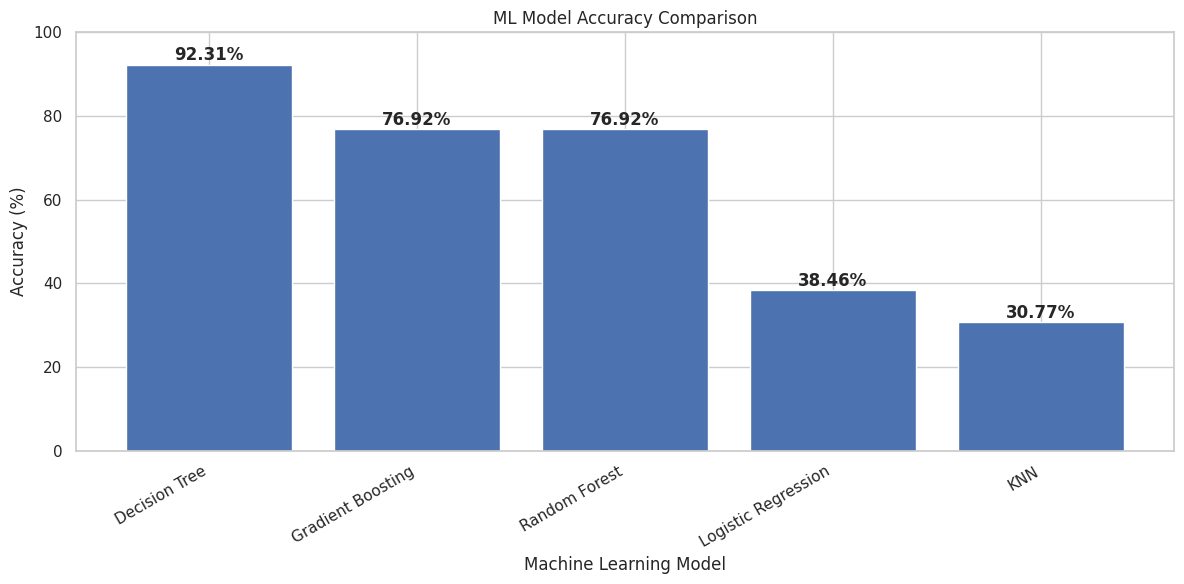

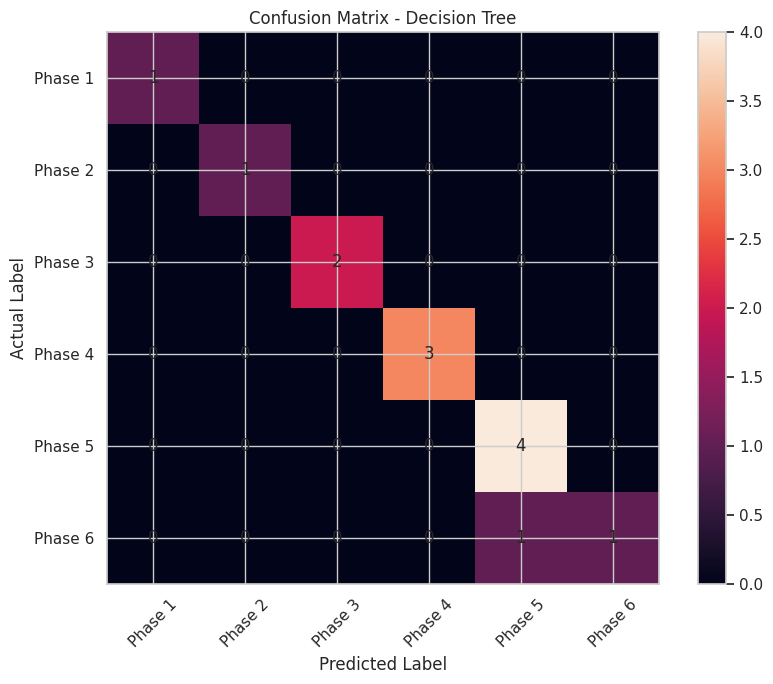

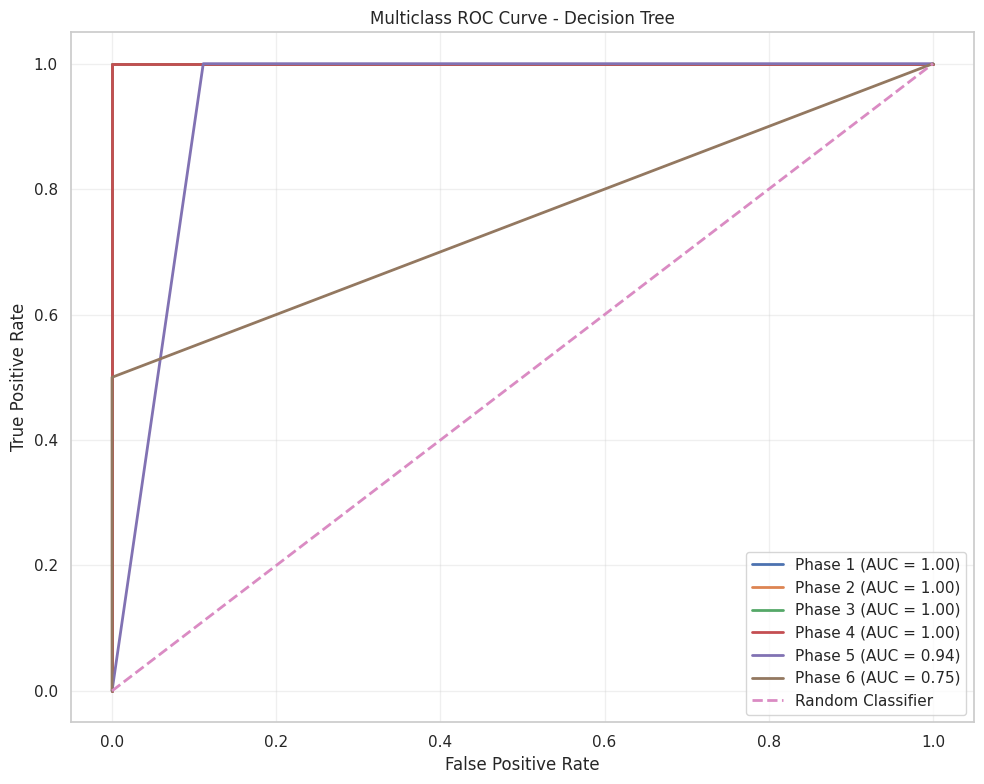


ROC-AUC SCORES
Phase 1: 1.0000
Phase 2: 1.0000
Phase 3: 1.0000
Phase 4: 1.0000
Phase 5: 0.9444
Phase 6: 0.7500


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)


print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

# ============================================================
# 3. Basic Cleaning
# ============================================================

# Remove duplicate rows
df = df.drop_duplicates().copy()

# Convert release_date to datetime
df["release_date"] = pd.to_datetime(
    df["release_date"],
    errors="coerce"
)

# Extract useful date features
df["release_year"] = df["release_date"].dt.year
df["release_month"] = df["release_date"].dt.month
df["release_day"] = df["release_date"].dt.day

# Drop original date and movie title
# Movie title has very high-cardinality text and is not useful
# for this classification model.
df = df.drop(columns=["release_date", "movie_title"], errors="ignore")

# ============================================================
# 4. Define Target
# ============================================================

target_column = "mcu_phase"

# Remove rows where target is missing
df = df.dropna(subset=[target_column]).copy()

X = df.drop(columns=[target_column])
y = df[target_column]

# ============================================================
# 5. Label Encoding
# ============================================================

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print("\nTarget Classes:")
for number, category in enumerate(label_encoder.classes_):
    print(number, "=", category)

# ============================================================
# 6. Convert Categorical Columns
# ============================================================

# Find categorical columns
categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\nCategorical Columns:")
print(categorical_columns)

# Label encode categorical feature columns
feature_label_encoders = {}

for column in categorical_columns:

    le = LabelEncoder()

    # Convert values to string so mixed data does not cause errors
    X[column] = X[column].astype(str)

    X[column] = le.fit_transform(X[column])

    feature_label_encoders[column] = le

# ============================================================
# 7. Convert All Columns to Numeric
# ============================================================

X = X.apply(pd.to_numeric, errors="coerce")

# ============================================================
# 8. Handle Missing Values
# ============================================================

imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("\nFinal Feature Columns:")
print(X.columns.tolist())

# ============================================================
# 9. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data :", X_test.shape)

# ============================================================
# 10. Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# 11. Define ML Algorithms
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=8
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        max_depth=10
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

# ============================================================
# 12. Train Models + Accuracy
# ============================================================

results = []

trained_models = {}

for model_name, model in models.items():

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    # KNN and Logistic Regression work well with scaled data.
    # Scaling is also harmless for the tree models.
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Precision
    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # Recall
    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # F1 Score
    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"Accuracy  : {accuracy * 100:.2f}%")
    print(f"Precision : {precision * 100:.2f}%")
    print(f"Recall    : {recall * 100:.2f}%")
    print(f"F1 Score  : {f1 * 100:.2f}%")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )

    results.append({
        "Model": model_name,
        "Accuracy (%)": accuracy * 100,
        "Precision (%)": precision * 100,
        "Recall (%)": recall * 100,
        "F1 Score (%)": f1 * 100
    })

    trained_models[model_name] = model

# ============================================================
# 13. Model Comparison
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy (%)",
    ascending=False
)

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print(results_df.round(2))

# ============================================================
# 14. Accuracy Visualization
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    results_df["Model"],
    results_df["Accuracy (%)"]
)

plt.title("ML Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.ylim(0, 100)

for i, value in enumerate(results_df["Accuracy (%)"]):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

# ============================================================
# 15. Confusion Matrix
# ============================================================

# Select the model with highest accuracy
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(9, 7))

plt.imshow(cm)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=45
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

# Add values inside matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

# ============================================================
# 16. MULTICLASS ROC CURVE
# ============================================================

# Number of classes
n_classes = len(label_encoder.classes_)

# Convert target into One-vs-Rest format
y_test_binary = label_binarize(
    y_test,
    classes=np.arange(n_classes)
)

# Get probability predictions
y_score = best_model.predict_proba(X_test_scaled)

# Store FPR, TPR and AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(
        y_test_binary[:, i],
        y_score[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

# ============================================================
# 17. Plot ROC Curve
# ============================================================

plt.figure(figsize=(10, 8))

for i in range(n_classes):

    plt.plot(
        fpr[i],
        tpr[i],
        linewidth=2,
        label=(
            f"{label_encoder.classes_[i]} "
            f"(AUC = {roc_auc[i]:.2f})"
        )
    )

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    f"Multiclass ROC Curve - {best_model_name}"
)

plt.legend(
    loc="lower right"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 18. Print AUC Scores
# ============================================================

print("\n" + "=" * 70)
print("ROC-AUC SCORES")
print("=" * 70)

for i in range(n_classes):

    print(
        f"{label_encoder.classes_[i]}: "
        f"{roc_auc[i]:.4f}"
    )

## Thank you..pls upvote!!!!!!!!!!